In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from scipy import stats
import matplotlib.widgets as widgets

In [2]:
def dataset(building_id=int,
            train_path ="dataset/train.csv",
            metadata_path = "dataset/building_metadata.csv",
            weather_path = "dataset/weather_train.csv"):
    train = pd.read_csv(train_path)
    metadata = pd.read_csv(metadata_path)
    weather = pd.read_csv(weather_path)

    return train, metadata, weather

In [3]:
train, metadata, weather = dataset()

print(train.head())

   building_id  meter            timestamp  meter_reading
0            0      0  2016-01-01 00:00:00            0.0
1            1      0  2016-01-01 00:00:00            0.0
2            2      0  2016-01-01 00:00:00            0.0
3            3      0  2016-01-01 00:00:00            0.0
4            4      0  2016-01-01 00:00:00            0.0


In [4]:
print(train['building_id'].value_counts().head())

building_id
1249    35136
1298    35136
1301    35128
1241    35116
1296    35115
Name: count, dtype: int64


In [7]:
building_id = 1298

train_b = train[(train['building_id'] == building_id) & (train['meter'].isin([0]))]

print(train_b.shape)
print(train_b.head())

(8784, 4)
       building_id  meter            timestamp  meter_reading
1993          1298      0  2016-01-01 00:00:00        416.169
4286          1298      0  2016-01-01 01:00:00        408.616
6585          1298      0  2016-01-01 02:00:00        412.072
8881          1298      0  2016-01-01 03:00:00        393.053
11177         1298      0  2016-01-01 04:00:00        404.519


In [8]:
train_b_pivot = train_b.pivot_table(
    index='timestamp',
    columns='meter',
    values='meter_reading'
).reset_index()

train_b_pivot.columns = ['timestamp', 'electricity']

print(train_b_pivot.shape)
print(train_b_pivot.head())

(8784, 2)
             timestamp  electricity
0  2016-01-01 00:00:00      416.169
1  2016-01-01 01:00:00      408.616
2  2016-01-01 02:00:00      412.072
3  2016-01-01 03:00:00      393.053
4  2016-01-01 04:00:00      404.519


In [9]:
train_b_pivot['building_id'] = building_id
metadata_b = metadata[metadata['building_id']== building_id]

train_b_pivot = train_b_pivot.merge(metadata_b, how='left', on='building_id')

print(train_b_pivot.head())

             timestamp  electricity  building_id  site_id primary_use  \
0  2016-01-01 00:00:00      416.169         1298       14   Education   
1  2016-01-01 01:00:00      408.616         1298       14   Education   
2  2016-01-01 02:00:00      412.072         1298       14   Education   
3  2016-01-01 03:00:00      393.053         1298       14   Education   
4  2016-01-01 04:00:00      404.519         1298       14   Education   

   square_feet  year_built  floor_count  
0       171084         NaN          NaN  
1       171084         NaN          NaN  
2       171084         NaN          NaN  
3       171084         NaN          NaN  
4       171084         NaN          NaN  


In [10]:
train_b_pivot = train_b_pivot.merge(
    weather,
    on=['site_id', 'timestamp'],
    how='left'
)

print(train_b_pivot.shape)
print(train_b_pivot.head())

(8784, 15)
             timestamp  electricity  building_id  site_id primary_use  \
0  2016-01-01 00:00:00      416.169         1298       14   Education   
1  2016-01-01 01:00:00      408.616         1298       14   Education   
2  2016-01-01 02:00:00      412.072         1298       14   Education   
3  2016-01-01 03:00:00      393.053         1298       14   Education   
4  2016-01-01 04:00:00      404.519         1298       14   Education   

   square_feet  year_built  floor_count  air_temperature  cloud_coverage  \
0       171084         NaN          NaN              NaN             NaN   
1       171084         NaN          NaN              5.6             0.0   
2       171084         NaN          NaN              5.6             4.0   
3       171084         NaN          NaN              5.6             NaN   
4       171084         NaN          NaN              5.0             NaN   

   dew_temperature  precip_depth_1_hr  sea_level_pressure  wind_direction  \
0              N

In [11]:
train_b_pivot = train_b_pivot.sort_values('timestamp')

train_b_pivot['electricity_lag_1'] = train_b_pivot['electricity'].shift(1)
train_b_pivot['electricity_lag_24'] = train_b_pivot['electricity'].shift(24)

train_b_pivot['electricity_roll_24'] = (
    train_b_pivot['electricity']
    .rolling(window=24)
    .mean()
)

In [12]:
def transform_data(df):
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['hour'] = df['timestamp'].dt.hour
    df['dayofweek'] = df['timestamp'].dt.dayofweek
    df['month'] = df['timestamp'].dt.month
    
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
   
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    
    return df

In [13]:
df_ready = transform_data(train_b_pivot)
df_final = df_ready[df_ready['electricity'] > 0].copy()

features = [
    'hour_sin', 'hour_cos', 'dayofweek', 'is_weekend', 
    'electricity_lag_1', 'electricity_lag_24', 'electricity_roll_24',
    'air_temperature'
]

df_ready['air_temperature'] = df_ready['air_temperature'].fillna(df_ready['air_temperature'].mean())

X = df_ready[features]
y = np.log1p(df_ready['electricity'])

clean_mask = X.notna().all(axis=1)
X_clean = X[clean_mask]
y_clean = y[clean_mask]

print(f"Deleted rows with NaN values: {len(X) - len(X_clean)}")
print(f"Final number of rows: {len(X_clean)}")

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, 
    test_size=0.2, 
    shuffle=False 
)

print(f"\nX_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")


Deleted rows with NaN values: 24
Final number of rows: 8760

X_train: (7008, 8)
X_test: (1752, 8)
X_train_scaled shape: (7008, 8)
X_test_scaled shape: (1752, 8)


In [14]:
weather_cols = ['air_temperature', 'cloud_coverage', 'dew_temperature', 
                'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed']

train_b_pivot[weather_cols] = train_b_pivot[weather_cols].interpolate(method='linear', limit_direction='both')

train_b_pivot[weather_cols] = train_b_pivot[weather_cols].ffill().bfill()

df_ready = transform_data(train_b_pivot)

df_ready = df_ready[df_ready['electricity'] > 0].copy()

lag_features = ['electricity_lag_1', 'electricity_lag_24', 'electricity_roll_24']
df_ready = df_ready.dropna(subset=lag_features).reset_index(drop=True)

print("NANs after cleaning:")
print(df_ready[features].isna().sum())

X = df_ready[features]
y = np.log1p(df_ready['electricity'])

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Deleted rows: {len(df_ready) - len(X)}")

NANs after cleaning:
hour_sin               0
hour_cos               0
dayofweek              0
is_weekend             0
electricity_lag_1      0
electricity_lag_24     0
electricity_roll_24    0
air_temperature        0
dtype: int64

X shape: (8133, 8)
y shape: (8133,)
Deleted rows: 0


In [15]:
train_b_pivot['timestamp'] = pd.to_datetime(train_b_pivot['timestamp'])

train_b_pivot['month'] = train_b_pivot['timestamp'].dt.month
train_b_pivot['month_sin'] = np.sin(2 * np.pi * train_b_pivot['month'] / 12)
train_b_pivot['month_cos'] = np.cos(2 * np.pi * train_b_pivot['month'] / 12)

train_b_pivot['day_of_year'] = train_b_pivot['timestamp'].dt.dayofyear
train_b_pivot['day_of_year_sin'] = np.sin(2 * np.pi * train_b_pivot['day_of_year'] / 365)
train_b_pivot['day_of_year_cos'] = np.cos(2 * np.pi * train_b_pivot['day_of_year'] / 365)

train_b_pivot['energy_per_m2'] = train_b_pivot['electricity'] / train_b_pivot['square_feet']

train_b_pivot['energy_per_m2'] = train_b_pivot['energy_per_m2'].replace([np.inf, -np.inf], np.nan)
train_b_pivot['energy_per_m2'] = train_b_pivot['energy_per_m2'].fillna(train_b_pivot['energy_per_m2'].median())

features_extended = [
    'hour_sin', 'hour_cos', 
    'dayofweek', 'is_weekend',
    'month_sin', 'month_cos',  
    'day_of_year_sin', 'day_of_year_cos',  
    'electricity_lag_1', 'electricity_lag_24', 'electricity_roll_24',
    'air_temperature',
    'energy_per_m2'  
]

print("New features:")
print([f for f in features_extended if f not in features])

New features:
['month_sin', 'month_cos', 'day_of_year_sin', 'day_of_year_cos', 'energy_per_m2']


In [16]:
df = train_b_pivot.copy()

df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month
df['day_of_year'] = df['timestamp'].dt.dayofyear
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['day_of_year_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['day_of_year_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365)

for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
    df[f'elec_lag_{lag}'] = df['electricity'].shift(lag)

for window in [6, 12, 24, 48, 168]:
    df[f'elec_roll_mean_{window}'] = df['electricity'].rolling(window=window, min_periods=1).mean()
    df[f'elec_roll_std_{window}'] = df['electricity'].rolling(window=window, min_periods=1).std()

df['elec_diff_1'] = df['electricity'].diff(1)
df['elec_diff_24'] = df['electricity'].diff(24)

for lag in [3, 6, 12, 24]:
    df[f'temp_lag_{lag}'] = df['air_temperature'].shift(lag)

for window in [6, 12, 24]:
    df[f'temp_roll_mean_{window}'] = df['air_temperature'].rolling(window=window, min_periods=1).mean()

df['temp_zone_cold'] = (df['air_temperature'] < 10).astype(int)
df['temp_zone_comfort'] = ((df['air_temperature'] >= 18) & (df['air_temperature'] <= 24)).astype(int)
df['temp_zone_hot'] = (df['air_temperature'] > 28).astype(int)

base_temp = 18.3
df['hdd'] = np.maximum(0, base_temp - df['air_temperature'])
df['cdd'] = np.maximum(0, df['air_temperature'] - base_temp)

df['energy_per_m2'] = df['electricity'] / df['square_feet']
df['energy_per_m2'] = df['energy_per_m2'].replace([np.inf, -np.inf], np.nan)

df = df[df['electricity'] > 0].copy()

print(f"after creating new features: {df.shape}")
print(f"NaN in electricity: {df['electricity'].isna().sum()}")

after creating new features: (8157, 62)
NaN in electricity: 0


In [17]:
lstm_features = [
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'day_of_year_sin', 'day_of_year_cos', 'is_weekend',
    'air_temperature', 'temp_lag_3', 'temp_lag_6', 'temp_lag_12',
    'elec_lag_1', 'elec_lag_2', 'elec_lag_3', 'elec_lag_24', 'elec_lag_48'
]

available_lstm_features = [f for f in lstm_features if f in df.columns]
print(f"available features for the LSTM: {len(available_lstm_features)}")
print(f"missing: {set(lstm_features) - set(available_lstm_features)}")

ml_features = [
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'day_of_year_sin', 'day_of_year_cos', 'dayofweek', 'is_weekend',
    'elec_lag_1', 'elec_lag_2', 'elec_lag_3', 'elec_lag_6', 
    'elec_lag_12', 'elec_lag_24', 'elec_lag_48', 'elec_lag_168',
    'elec_roll_mean_6', 'elec_roll_mean_12', 'elec_roll_mean_24',
    'elec_roll_mean_48', 'elec_roll_mean_168',
    'elec_roll_std_24', 'elec_roll_std_168',
    'elec_diff_1', 'elec_diff_24',
    'air_temperature', 'temp_lag_3', 'temp_lag_6', 'temp_lag_12', 'temp_lag_24',
    'temp_roll_mean_6', 'temp_roll_mean_12', 'temp_roll_mean_24',
    'temp_zone_cold', 'temp_zone_comfort', 'temp_zone_hot',
    'hdd', 'cdd', 'energy_per_m2'
]

available_ml_features = [f for f in ml_features if f in df.columns]
print(f"available features for the LSTM: {len(available_ml_features)}")

available features for the LSTM: 16
missing: set()
available features for the LSTM: 39


In [18]:
def create_sequences(data, target, seq_length=24):
    
    X_seq, y_seq = [], []
    for i in range(len(data) - seq_length):
        X_seq.append(data[i:i+seq_length])
        y_seq.append(target[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

seq_length = 24

lstm_data = df[available_lstm_features].copy()
target = df['electricity'].values

target_log = np.log1p(target)

clean_mask = lstm_data.notna().all(axis=1)
lstm_data_clean = lstm_data[clean_mask]
target_clean = target_log[clean_mask]

print(f"number of rows after deleting NaN values for the LSTM: {len(lstm_data_clean)}")

X_lstm, y_lstm = create_sequences(
    lstm_data_clean.values,
    target_clean,
    seq_length
)

print(f"LSTM data: X={X_lstm.shape}, y={y_lstm.shape}")

scaler_lstm = StandardScaler()

X_lstm_reshaped = X_lstm.reshape(-1, X_lstm.shape[-1])
X_lstm_scaled = scaler_lstm.fit_transform(X_lstm_reshaped)
X_lstm_scaled = X_lstm_scaled.reshape(X_lstm.shape)

print(f"after normalization: {X_lstm_scaled.shape}")

number of rows after deleting NaN values for the LSTM: 8109
LSTM data: X=(8085, 24, 16), y=(8085,)
after normalization: (8085, 24, 16)


In [19]:
ml_data = df[available_ml_features].copy()
target_ml = df['electricity'].values

target_ml_log = np.log1p(target_ml)

clean_mask_ml = ml_data.notna().all(axis=1)
ml_data_clean = ml_data[clean_mask_ml]
target_ml_clean = target_ml_log[clean_mask_ml]

print(f"number of rows after deleting NaN values for ML: {len(ml_data_clean)}")

scaler_ml = StandardScaler()
X_ml_scaled = scaler_ml.fit_transform(ml_data_clean)

print(f"LightGBM data: X={X_ml_scaled.shape}, y={target_ml_clean.shape}")

number of rows after deleting NaN values for ML: 7989
LightGBM data: X=(7989, 39), y=(7989,)


In [20]:
train_size_lstm = int(len(X_lstm_scaled) * 0.8)

X_lstm_train = X_lstm_scaled[:train_size_lstm]
y_lstm_train = y_lstm[:train_size_lstm]
X_lstm_test = X_lstm_scaled[train_size_lstm:]
y_lstm_test = y_lstm[train_size_lstm:]

print(f"LSTM train: {X_lstm_train.shape}, test: {X_lstm_test.shape}")

start_idx = seq_length
X_ml_aligned = X_ml_scaled[start_idx:]
y_ml_aligned = target_ml_clean[start_idx:]

train_size_ml = int(len(X_ml_aligned) * 0.8)

X_ml_train = X_ml_aligned[:train_size_ml]
y_ml_train = y_ml_aligned[:train_size_ml]
X_ml_test = X_ml_aligned[train_size_ml:]
y_ml_test = y_ml_aligned[train_size_ml:]

print(f"LightGBM train: {X_ml_train.shape}, test: {X_ml_test.shape}")

LSTM train: (6468, 24, 16), test: (1617, 24, 16)
LightGBM train: (6372, 39), test: (1593, 39)


In [21]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.5):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.dropout(lstm_out[:, -1, :])
        return self.fc(out).squeeze()

def train_lstm(model, X_train, y_train, X_val, y_val, epochs=100, batch_size=32, lr=0.001):
    X_train_tensor = torch.FloatTensor(X_train)
    y_train_tensor = torch.FloatTensor(y_train)
    X_val_tensor = torch.FloatTensor(X_val)
    y_val_tensor = torch.FloatTensor(y_val)
    
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)  
    criterion = nn.MSELoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    
    train_losses, val_losses = [], []
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            if torch.isnan(loss):
                continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()
        
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_tensor), y_val_tensor)
        
        train_losses.append(epoch_loss / len(train_loader))
        val_losses.append(val_loss.item())
        scheduler.step(val_loss)
        
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_losses[-1]:.6f} | Val Loss: {val_losses[-1]:.6f}")
    
    return train_losses, val_losses

In [22]:
df_clean = df.copy()
df_clean['target_log'] = np.log1p(df_clean['electricity'])

ml_clean = df_clean[available_ml_features].notna().all(axis=1)
valid_ml_indices = df_clean.index[ml_clean].tolist()

valid_lstm_indices = []
seq_length = 24
for i in range(seq_length, len(df_clean)):
    window = df_clean[available_lstm_features].iloc[i-seq_length:i]
    if window.notna().all().all():
        valid_lstm_indices.append(i)

common_indices = sorted(set(valid_lstm_indices) & set(valid_ml_indices))
print(f"Common indices: {len(common_indices)}")

X_lstm_sync, X_ml_sync, y_sync = [], [], []
for idx in common_indices:
    start = idx - seq_length
    X_lstm_sync.append(df_clean[available_lstm_features].iloc[start:idx].values)
    X_ml_sync.append(df_clean[available_ml_features].iloc[idx].values)
    y_sync.append(df_clean['target_log'].iloc[idx])

X_lstm_sync = np.array(X_lstm_sync)
X_ml_sync = np.array(X_ml_sync)
y_sync = np.array(y_sync)

print(f"X_lstm_sync: {X_lstm_sync.shape}")
print(f"X_ml_sync: {X_ml_sync.shape}")
print(f"y_sync: {y_sync.shape}")

Common indices: 7371
X_lstm_sync: (7371, 24, 16)
X_ml_sync: (7371, 39)
y_sync: (7371,)


In [23]:
scaler_lstm = StandardScaler()
X_lstm_reshaped = X_lstm_sync.reshape(-1, X_lstm_sync.shape[-1])
X_lstm_scaled = scaler_lstm.fit_transform(X_lstm_reshaped).reshape(X_lstm_sync.shape)

scaler_ml = StandardScaler()
X_ml_scaled = scaler_ml.fit_transform(X_ml_sync)

split = int(len(X_lstm_scaled) * 0.8)
X_lstm_train = X_lstm_scaled[:split]
X_lstm_test = X_lstm_scaled[split:]
X_ml_train = X_ml_scaled[:split]
X_ml_test = X_ml_scaled[split:]
y_train = y_sync[:split]
y_test = y_sync[split:]

print(f"Train: {len(y_train)}, Test: {len(y_test)}")

Train: 5896, Test: 1475


In [24]:
lstm_model = LSTMModel(input_size=len(available_lstm_features), hidden_size=32, num_layers=1)
train_losses, val_losses = train_lstm(lstm_model, X_lstm_train, y_train, X_lstm_test, y_test, epochs=100)

with torch.no_grad():
    lstm_preds = lstm_model(torch.FloatTensor(X_lstm_test)).numpy()

print(f"\nLSTM STREAM RESULTS:")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lstm_preds)):.4f}")
print(f"R²: {r2_score(y_test, lstm_preds):.4f}")

Epoch 20/100 | Train Loss: 0.424823 | Val Loss: 0.117460
Epoch 40/100 | Train Loss: 0.054980 | Val Loss: 0.007999
Epoch 60/100 | Train Loss: 0.010220 | Val Loss: 0.009493
Epoch 80/100 | Train Loss: 0.007044 | Val Loss: 0.011287
Epoch 100/100 | Train Loss: 0.006526 | Val Loss: 0.011649

LSTM STREAM RESULTS:
RMSE: 0.1079
R²: 0.4670


In [25]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=60,           
    learning_rate=0.02,        
    max_depth=4,               
    num_leaves=15,             
    reg_alpha=0.2,            
    reg_lambda=0.2,            
    min_child_samples=40,      
    subsample=0.7,             
    colsample_bytree=0.7,      
    random_state=42,
    verbose=-1
)

lgb_model.fit(X_ml_train, y_train, 
              eval_set=[(X_ml_test, y_test)], 
              callbacks=[lgb.early_stopping(15)])  

y_pred = lgb_model.predict(X_ml_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"\n[2] Performance Metrics:")
print(f"    RMSE: {rmse:.6f}")
print(f"    R²:   {r2:.6f}")
print(f"    MAE:  {mae:.6f}")

Training until validation scores don't improve for 15 rounds
Did not meet early stopping. Best iteration is:
[60]	valid_0's l2: 0.0013956

[2] Performance Metrics:
    RMSE: 0.037358
    R²:   0.936137
    MAE:  0.025561


In [54]:
total_len = len(X_lstm_scaled)
train_size = int(total_len * 0.7)
val_size = int(total_len * 0.15)
test_size = total_len - train_size - val_size

print(f"Train: {train_size}, Validation: {val_size}, Test: {test_size}")

X_lstm_train = X_lstm_scaled[:train_size]
X_lstm_val = X_lstm_scaled[train_size:train_size+val_size]
X_lstm_test = X_lstm_scaled[train_size+val_size:]

X_ml_train = X_ml_scaled[:train_size]
X_ml_val = X_ml_scaled[train_size:train_size+val_size]
X_ml_test = X_ml_scaled[train_size+val_size:]

y_train = y_sync[:train_size]
y_val = y_sync[train_size:train_size+val_size]
y_test = y_sync[train_size+val_size:]

print(f"LSTM shapes: train {X_lstm_train.shape}, val {X_lstm_val.shape}, test {X_lstm_test.shape}")
print(f"LightGBM shapes: train {X_ml_train.shape}, val {X_ml_val.shape}, test {X_ml_test.shape}")

with torch.no_grad():
    lstm_val_preds = lstm_model(torch.FloatTensor(X_lstm_val)).detach().numpy()
lgb_val_preds = lgb_model.predict(X_ml_val)

X_meta_val = np.column_stack([lstm_val_preds, lgb_val_preds])
meta_model = Ridge(alpha=1.0)
meta_model.fit(X_meta_val, y_val)

print(f"Meta-model weights - LSTM: {meta_model.coef_[0]:.3f}, LightGBM: {meta_model.coef_[1]:.3f}")

with torch.no_grad():
    lstm_test_preds = lstm_model(torch.FloatTensor(X_lstm_test)).detach().numpy()
lgb_test_preds = lgb_model.predict(X_ml_test)

X_meta_test = np.column_stack([lstm_test_preds, lgb_test_preds])
dual_preds = meta_model.predict(X_meta_test)

print(f"\nDUAL-STREAM RESULTS:")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, dual_preds)):.4f}")
print(f"R²: {r2_score(y_test, dual_preds):.4f}")
print(f"MAE: {mean_absolute_error(y_test, dual_preds):.4f}")

Train: 5159, Validation: 1105, Test: 1107
LSTM shapes: train (5159, 24, 16), val (1105, 24, 16), test (1107, 24, 16)
LightGBM shapes: train (5159, 39), val (1105, 39), test (1107, 39)
Meta-model weights - LSTM: 0.169, LightGBM: 1.246

DUAL-STREAM RESULTS:
RMSE: 0.0226
R²: 0.9804
MAE: 0.0109



TOP 10 FEATURES:
         feature  importance
   energy_per_m2         351
      elec_lag_1          33
    elec_diff_24          23
elec_roll_mean_6          23
 day_of_year_cos          20
     elec_diff_1          18
    elec_lag_168          11
        hour_cos           9
 day_of_year_sin           8
      elec_lag_2           8


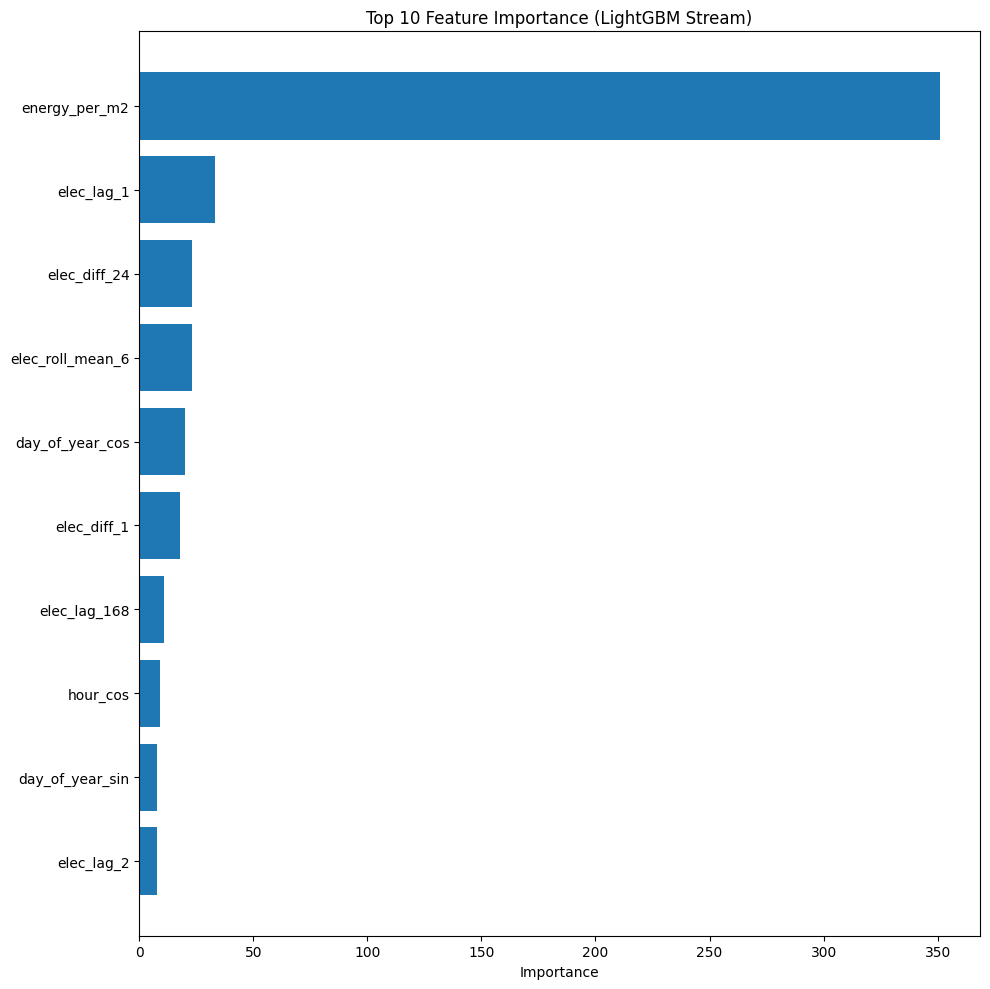

In [27]:
importance_df = pd.DataFrame({
    'feature': available_ml_features,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTOP 10 FEATURES:")
print(importance_df.head(10).to_string(index=False))

plt.figure(figsize=(10, 10))
plt.barh(importance_df['feature'].head(10), importance_df['importance'].head(10))
plt.xlabel('Importance')
plt.title('Top 10 Feature Importance (LightGBM Stream)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Обрезаем до 1107 элементов


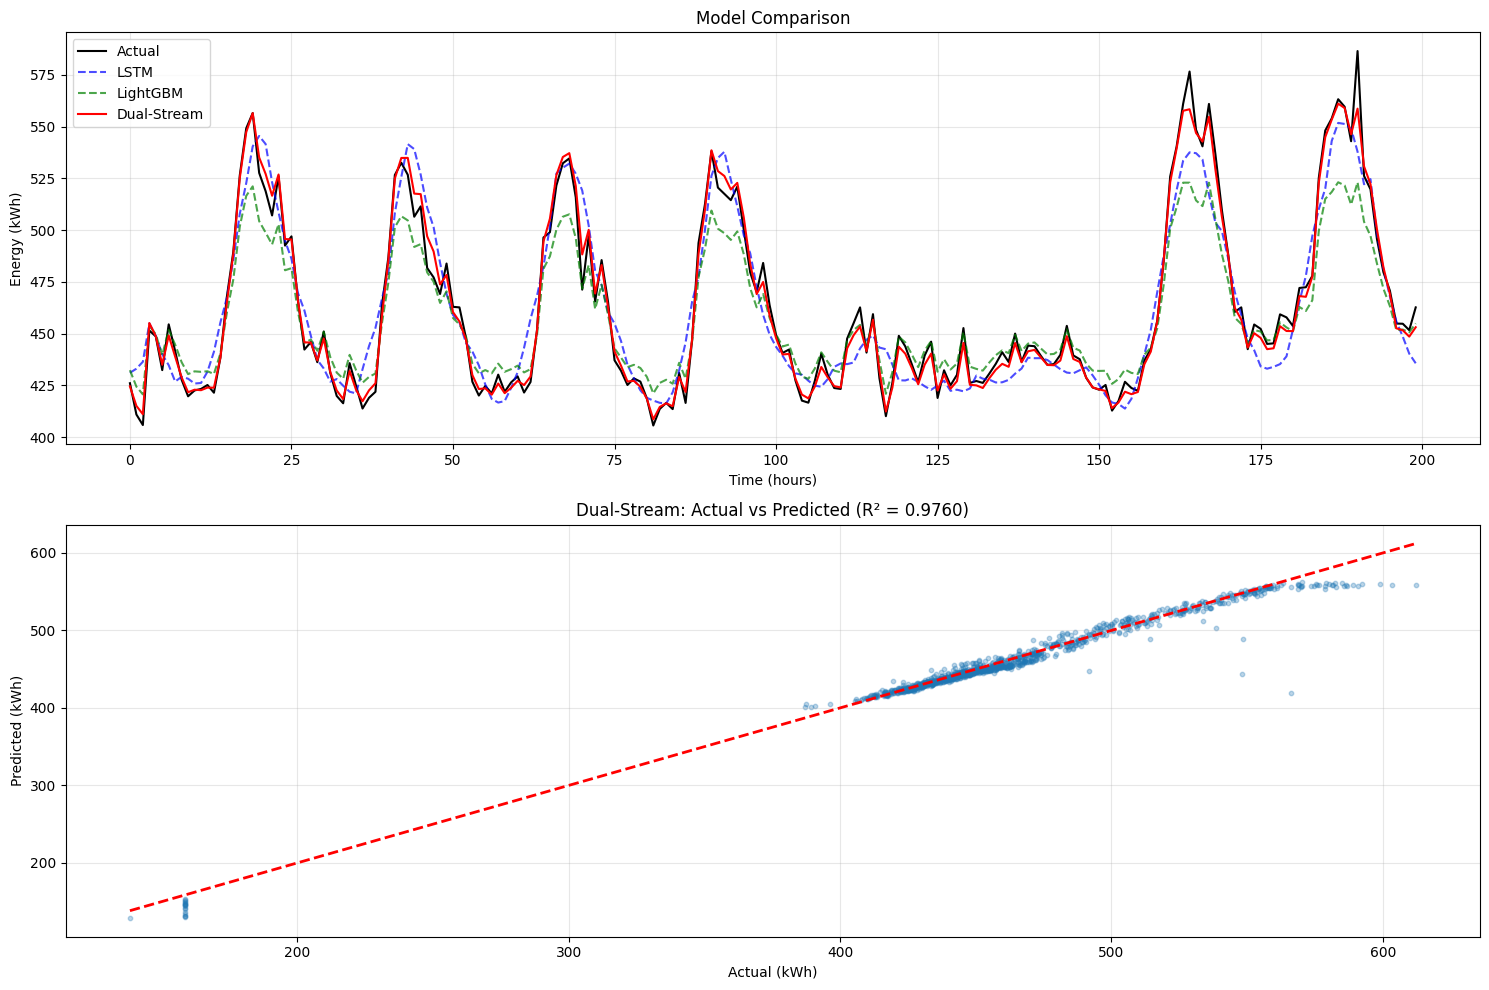

In [28]:
min_len = min(len(y_test), len(dual_preds), len(lstm_test_preds), len(lgb_test_preds))
print(f"Обрезаем до {min_len} элементов")

y_test_trim = y_test[:min_len]
dual_preds_trim = dual_preds[:min_len]
lstm_preds_trim = lstm_test_preds[:min_len]
lgb_preds_trim = lgb_test_preds[:min_len]

y_original = np.expm1(y_test_trim)
dual_original = np.expm1(dual_preds_trim)
lstm_original = np.expm1(lstm_preds_trim)
lgb_original = np.expm1(lgb_preds_trim)

plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.plot(y_original[:200], 'k-', linewidth=1.5, label='Actual')
plt.plot(lstm_original[:200], 'b--', alpha=0.7, label='LSTM')
plt.plot(lgb_original[:200], 'g--', alpha=0.7, label='LightGBM')
plt.plot(dual_original[:200], 'r-', linewidth=1.5, label='Dual-Stream')
plt.xlabel('Time (hours)')
plt.ylabel('Energy (kWh)')
plt.title('Model Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.scatter(y_original, dual_original, alpha=0.3, s=10)
plt.plot([y_original.min(), y_original.max()], 
         [y_original.min(), y_original.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual (kWh)')
plt.ylabel('Predicted (kWh)')
plt.title(f'Dual-Stream: Actual vs Predicted (R² = {r2_score(y_original, dual_original):.4f})')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ValueError: too many values to unpack (expected 2)

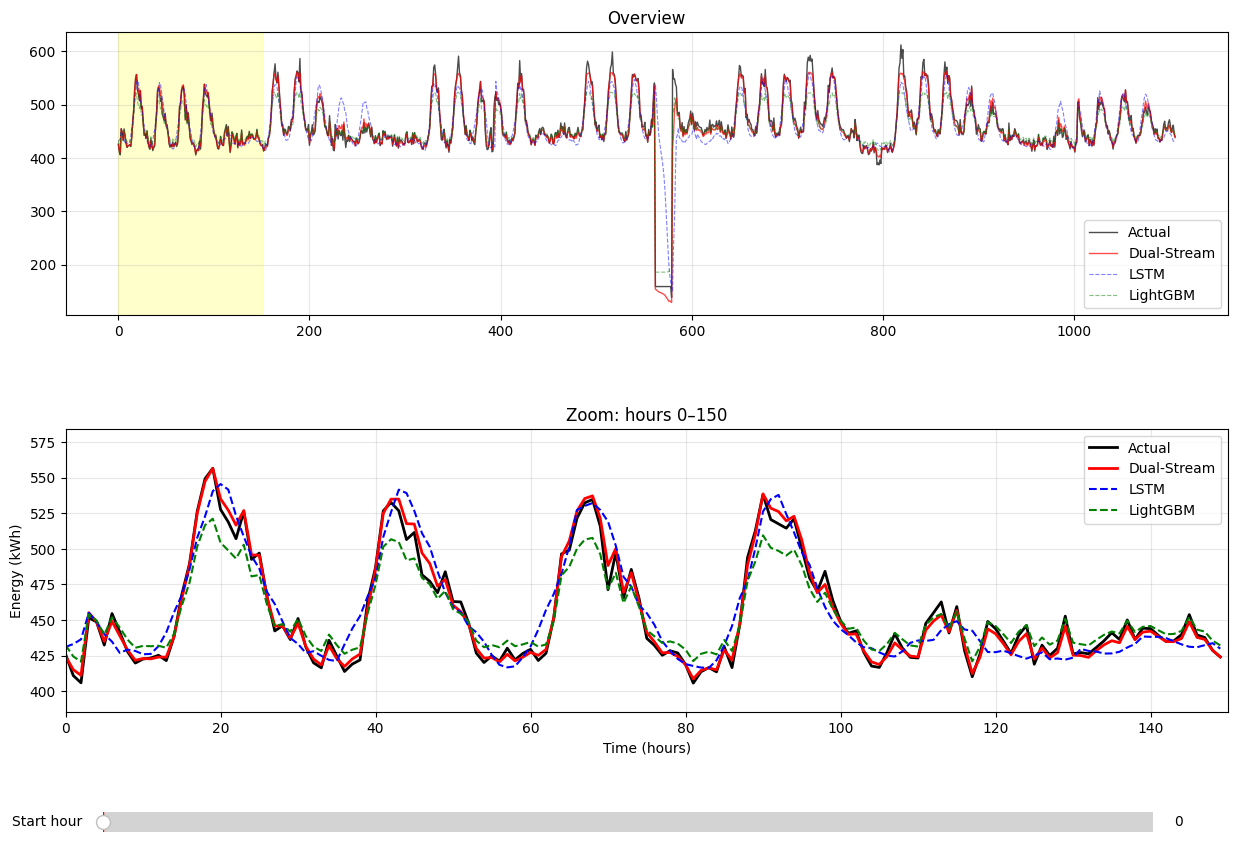

In [29]:
window = 150

fig, (ax_main, ax_detail) = plt.subplots(2, 1, figsize=(15, 10))
plt.subplots_adjust(bottom=0.2, hspace=0.4)

ax_main.plot(y_original, 'k-', linewidth=1, label='Actual', alpha=0.7)
ax_main.plot(dual_original, 'r-', linewidth=1, label='Dual-Stream', alpha=0.7)
ax_main.plot(lstm_original, 'b--', linewidth=0.8, label='LSTM', alpha=0.5)
ax_main.plot(lgb_original, 'g--', linewidth=0.8, label='LightGBM', alpha=0.5)
ax_main.set_title("Overview")
ax_main.legend()
ax_main.grid(True, alpha=0.3)

zoom_rect = ax_main.axvspan(0, window, alpha=0.2, color='yellow')

l_actual, = ax_detail.plot([], [], 'k-', linewidth=2, label='Actual')
l_dual,   = ax_detail.plot([], [], 'r-', linewidth=2, label='Dual-Stream')
l_lstm,   = ax_detail.plot([], [], 'b--', linewidth=1.5, label='LSTM')
l_lgb,    = ax_detail.plot([], [], 'g--', linewidth=1.5, label='LightGBM')
ax_detail.legend()
ax_detail.grid(True, alpha=0.3)
ax_detail.set_xlabel("Time (hours)")
ax_detail.set_ylabel("Energy (kWh)")

metrics_text = ax_detail.text(0.02, 0.95, '', transform=ax_detail.transAxes,
                               verticalalignment='top', fontsize=9,
                               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

def update(val):
    start = int(slider.val)
    end   = min(start + window, len(y_original))
    
    x = np.arange(start, end)
    l_actual.set_data(x, y_original[start:end])
    l_dual.set_data(x,   dual_original[start:end])
    l_lstm.set_data(x,   lstm_original[start:end])
    l_lgb.set_data(x,    lgb_original[start:end])
    
    ax_detail.set_xlim(start, end)
    y_min = min(y_original[start:end].min(), dual_original[start:end].min()) * 0.95
    y_max = max(y_original[start:end].max(), dual_original[start:end].max()) * 1.05
    ax_detail.set_ylim(y_min, y_max)
    ax_detail.set_title(f"Zoom: hours {start}–{end}")
    
    zoom_rect.set_xy([[start, 0], [start, 1], [end, 1], [end, 0], [start, 0]])
    
  
    from sklearn.metrics import mean_absolute_error, r2_score
    mae_w  = mean_absolute_error(y_original[start:end], dual_original[start:end])
    r2_w   = r2_score(y_original[start:end], dual_original[start:end])
    bias_w = np.mean(dual_original[start:end] - y_original[start:end])
    metrics_text.set_text(f"Window metrics (Dual):\nMAE={mae_w:.2f}  R²={r2_w:.4f}  Bias={bias_w:+.2f}")
    
    fig.canvas.draw_idle()


ax_slider = plt.axes([0.15, 0.07, 0.70, 0.04])
slider = widgets.Slider(ax_slider, 'Start hour', 0, len(y_original) - window, valinit=0, valstep=1)
slider.on_changed(update)

update(0)
plt.show()


Mean Error: 2.0239 kWh
Std Error: 8.6642 kWh
Max Underestimate: -17.7224 kWh
Max Overestimate: 147.2551 kWh


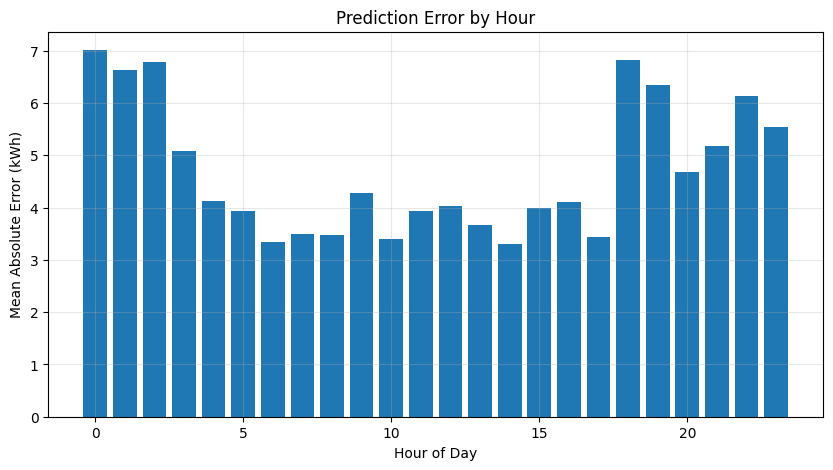

In [30]:
min_len = min(len(y_test), len(dual_preds))

y_test_sync = y_test[:min_len]
dual_preds_sync = dual_preds[:min_len]

residuals = np.expm1(y_test_sync) - np.expm1(dual_preds_sync)

print(f"\nMean Error: {np.mean(residuals):.4f} kWh")
print(f"Std Error: {np.std(residuals):.4f} kWh")
print(f"Max Underestimate: {np.min(residuals):.4f} kWh")
print(f"Max Overestimate: {np.max(residuals):.4f} kWh")

hourly_errors = []

hours_in_test = df_clean['hour'].iloc[common_indices[split:]][:min_len].values

for hour in range(24):
    hour_mask = hours_in_test == hour
    if hour_mask.any():
        hourly_errors.append(np.mean(np.abs(residuals[hour_mask])))
    else:
        hourly_errors.append(0) 

plt.figure(figsize=(10, 5))
plt.bar(range(24), hourly_errors)
plt.xlabel('Hour of Day')
plt.ylabel('Mean Absolute Error (kWh)')
plt.title('Prediction Error by Hour')
plt.grid(True, alpha=0.3)
plt.show()

In [31]:
min_len = min(len(y_test), len(dual_preds), len(lstm_test_preds), len(lgb_test_preds))

y_true_orig  = np.expm1(y_test[:min_len])
dual_orig    = np.expm1(dual_preds[:min_len])
lstm_orig    = np.expm1(lstm_test_preds[:min_len])
lgb_orig     = np.expm1(lgb_test_preds[:min_len])

residuals_dual = y_true_orig - dual_orig
residuals_lstm = y_true_orig - lstm_orig
residuals_lgb  = y_true_orig - lgb_orig

print("Residual Statistics")
for name, res in [("Dual-Stream", residuals_dual), ("LSTM", residuals_lstm), ("LightGBM", residuals_lgb)]:
    print(f"\n{name}:")
    print(f"  Mean Error (bias):  {np.mean(res):+.4f}")
    print(f"  Std Dev:            {np.std(res):.4f}")
    print(f"  MAE:                {np.mean(np.abs(res)):.4f}")
    print(f"  RMSE:               {np.sqrt(np.mean(res**2)):.4f}")
    print(f"  Max Overestimate:   {np.max(res):+.4f}")
    print(f"  Max Underestimate:  {np.min(res):+.4f}")
    sk = stats.skew(res)
    ku = stats.kurtosis(res)
    print(f"  Skewness:           {sk:.4f}")
    print(f"  Kurtosis:           {ku:.4f}")

Residual Statistics

Dual-Stream:
  Mean Error (bias):  +2.0239
  Std Dev:            8.6642
  MAE:                4.7015
  RMSE:               8.8975
  Max Overestimate:   +147.2551
  Max Underestimate:  -17.7224
  Skewness:           6.7725
  Kurtosis:           91.5714

LSTM:
  Mean Error (bias):  +1.8156
  Std Dev:            38.7237
  MAE:                18.2710
  RMSE:               38.7662
  Max Overestimate:   +416.0725
  Max Underestimate:  -379.3651
  Skewness:           -2.1734
  Kurtosis:           47.7615

LightGBM:
  Mean Error (bias):  +5.3587
  Std Dev:            16.3410
  MAE:                11.4979
  RMSE:               17.1972
  Max Overestimate:   +89.2182
  Max Underestimate:  -52.1166
  Skewness:           1.3365
  Kurtosis:           2.8592


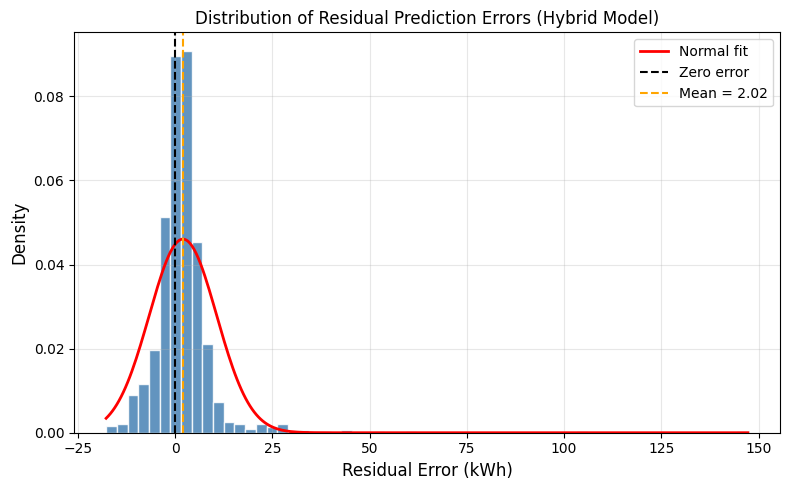

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(residuals_dual, bins=60, color='steelblue', edgecolor='white', 
        alpha=0.85, density=True)

x_range = np.linspace(residuals_dual.min(), residuals_dual.max(), 300)
ax.plot(x_range, stats.norm.pdf(x_range, np.mean(residuals_dual), np.std(residuals_dual)),
        'r-', linewidth=2, label='Normal fit')

ax.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Zero error')
ax.axvline(np.mean(residuals_dual), color='orange', linestyle='--', 
           linewidth=1.5, label=f'Mean = {np.mean(residuals_dual):.2f}')

ax.set_xlabel('Residual Error (kWh)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Distribution of Residual Prediction Errors (Hybrid Model)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure_4_4_residual_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

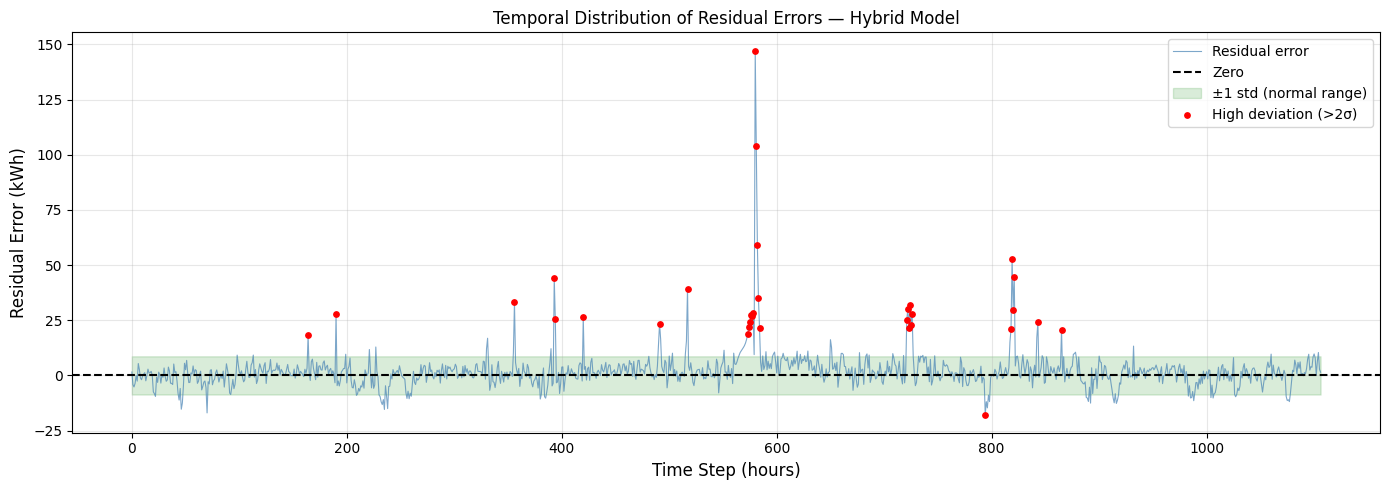

In [33]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(residuals_dual, color='steelblue', linewidth=0.8, alpha=0.7, label='Residual error')
ax.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Zero')
ax.fill_between(range(len(residuals_dual)),
                -np.std(residuals_dual), np.std(residuals_dual),
                alpha=0.15, color='green', label='±1 std (normal range)')

threshold = 2 * np.std(residuals_dual)
outlier_mask = np.abs(residuals_dual) > threshold
ax.scatter(np.where(outlier_mask)[0], residuals_dual[outlier_mask],
           color='red', s=15, zorder=5, label='High deviation (>2σ)')

ax.set_xlabel('Time Step (hours)', fontsize=12)
ax.set_ylabel('Residual Error (kWh)', fontsize=12)
ax.set_title('Temporal Distribution of Residual Errors — Hybrid Model', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure_4_5_residual_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
min_len = min(len(y_test), len(dual_preds), len(lstm_test_preds), len(lgb_test_preds))

test_data = pd.DataFrame({
    'y_true': y_test[:min_len],
    'dual_pred': dual_preds[:min_len],
    'lstm_pred': lstm_test_preds[:min_len],
    'lgb_pred': lgb_test_preds[:min_len]
})

baseline_preds = np.ones_like(test_data['y_true']) * np.mean(test_data['y_true'])
baseline_rmse = np.sqrt(mean_squared_error(test_data['y_true'], baseline_preds))
baseline_r2 = r2_score(test_data['y_true'], baseline_preds)

dual_rmse = np.sqrt(mean_squared_error(test_data['y_true'], test_data['dual_pred']))
dual_r2 = r2_score(test_data['y_true'], test_data['dual_pred'])

print(f"Baseline (mean) - RMSE: {baseline_rmse:.4f}, R²: {baseline_r2:.4f}")
print(f"Dual-Stream   - RMSE: {dual_rmse:.4f}, R²: {dual_r2:.4f}")
print(f"Improvement   - RMSE: {(1 - dual_rmse/baseline_rmse)*100:.1f}%")

Baseline (mean) - RMSE: 0.1615, R²: 0.0000
Dual-Stream   - RMSE: 0.0226, R²: 0.9804
Improvement   - RMSE: 86.0%


scenario-based for virtual plant

Temperature -5°C: 510916.07 kWh (+0.60%)
Temperature -2°C: 509419.74 kWh (+0.31%)
Temperature +0°C: 507855.49 kWh (+0.00%)
Temperature +2°C: 506475.28 kWh (-0.27%)
Temperature +5°C: 504612.19 kWh (-0.64%)


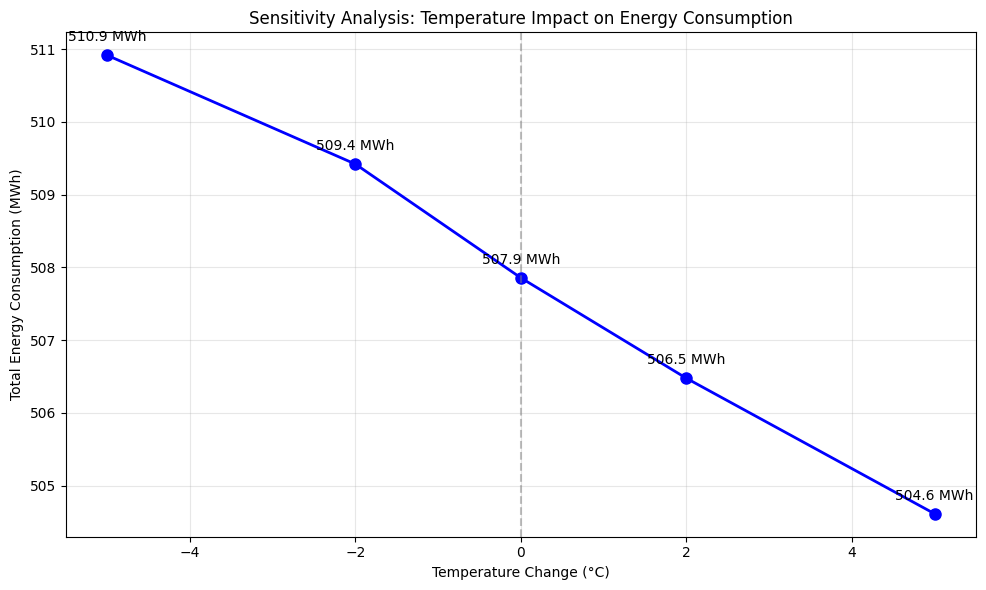

In [35]:
def simulate_scenario(model_lstm, model_ml, meta_model, 
                      X_lstm, X_ml, 
                      temp_change=0, 
                      weather_change=None,
                      load_factor=1.0):
   
    X_lstm_scenario = X_lstm.copy()
    X_ml_scenario = X_ml.copy()
    
    if temp_change != 0:
        if 'air_temperature' in available_lstm_features:
            temp_idx = available_lstm_features.index('air_temperature')
            X_lstm_scenario[:, :, temp_idx] += temp_change
        
        if 'air_temperature' in available_ml_features:
            ml_temp_idx = available_ml_features.index('air_temperature')
            X_ml_scenario[:, ml_temp_idx] += temp_change
   
    if weather_change:
        for feature, delta in weather_change.items():
            if feature in available_lstm_features:
                feat_idx = available_lstm_features.index(feature)
                X_lstm_scenario[:, :, feat_idx] += delta
            
            if feature in available_ml_features:
                feat_idx = available_ml_features.index(feature)
                X_ml_scenario[:, feat_idx] += delta
 
    if load_factor != 1.0:
        pass

    with torch.no_grad():
        lstm_pred = model_lstm(torch.FloatTensor(X_lstm_scenario)).numpy()
    ml_pred = model_ml.predict(X_ml_scenario)
    
    X_meta = np.column_stack([lstm_pred, ml_pred])
    hybrid_pred = meta_model.predict(X_meta)
    
    return hybrid_pred

baseline_preds = dual_preds.copy()
y_actual = y_test.copy()

scenarios_temp = [-5, -2, 0, +2, +5]
temp_results = []

for delta_temp in scenarios_temp:
    preds = simulate_scenario(
        lstm_model, lgb_model, meta_model,
        X_lstm_test, X_ml_test,
        temp_change=delta_temp
    )
    
    total_energy = np.sum(np.expm1(preds))
    temp_results.append({
        'delta_temp': delta_temp,
        'total_energy': total_energy,
        'change_pct': (total_energy / np.sum(np.expm1(baseline_preds)) - 1) * 100
    })
    
    print(f"Temperature {delta_temp:+d}°C: {total_energy:.2f} kWh "
          f"({temp_results[-1]['change_pct']:+.2f}%)")

plt.figure(figsize=(10, 6))
temps = [r['delta_temp'] for r in temp_results]
energy = [r['total_energy'] / 1000 for r in temp_results] 

plt.plot(temps, energy, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Temperature Change (°C)')
plt.ylabel('Total Energy Consumption (MWh)')
plt.title('Sensitivity Analysis: Temperature Impact on Energy Consumption')
plt.grid(True, alpha=0.3)

for i, (t, e) in enumerate(zip(temps, energy)):
    plt.annotate(f'{e:.1f} MWh', (t, e), textcoords="offset points", 
                 xytext=(0,10), ha='center')

plt.tight_layout()
plt.show()

Normal      : 507855.49 kWh (+0.00%)
Heat Wave   : 504612.19 kWh (-0.64%)
Cold Snap   : 510916.07 kWh (+0.60%)
Stormy      : 507855.49 kWh (+0.00%)
Cloudy      : 507855.49 kWh (+0.00%)
Sunny       : 505807.83 kWh (-0.40%)


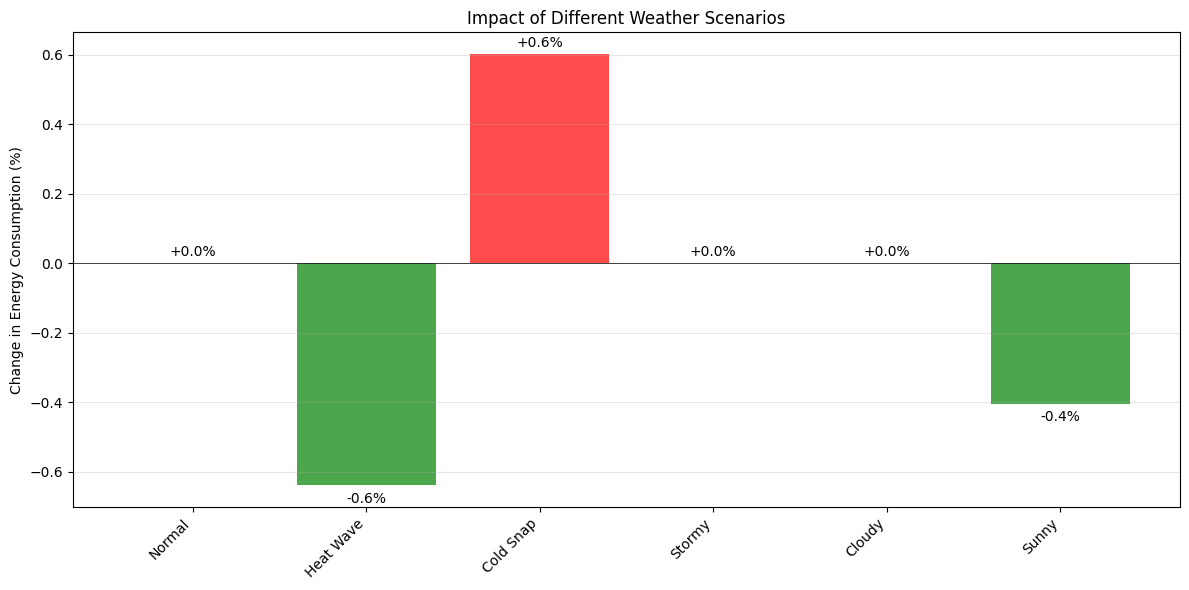

In [36]:
weather_scenarios = {
    'Normal': {},
    'Heat Wave': {'air_temperature': +5, 'cloud_coverage': -20},
    'Cold Snap': {'air_temperature': -5, 'cloud_coverage': +30},
    'Stormy': {'wind_speed': +15, 'cloud_coverage': +40, 'precip_depth_1_hr': +5},
    'Cloudy': {'cloud_coverage': +50},
    'Sunny': {'cloud_coverage': -40, 'air_temperature': +3}
}

weather_results = []

for scenario_name, weather_changes in weather_scenarios.items():
    preds = simulate_scenario(
        lstm_model, lgb_model, meta_model,
        X_lstm_test, X_ml_test,
        weather_change=weather_changes
    )
    
    total_energy = np.sum(np.expm1(preds))
    baseline_total = np.sum(np.expm1(baseline_preds))
    change_pct = (total_energy / baseline_total - 1) * 100
    
    weather_results.append({
        'scenario': scenario_name,
        'total_energy': total_energy,
        'change_pct': change_pct
    })
    
    print(f"{scenario_name:12s}: {total_energy:.2f} kWh ({change_pct:+.2f}%)")

plt.figure(figsize=(12, 6))
scenarios = [r['scenario'] for r in weather_results]
changes = [r['change_pct'] for r in weather_results]
colors = ['green' if c < 0 else 'red' if c > 0 else 'blue' for c in changes]

bars = plt.bar(scenarios, changes, color=colors, alpha=0.7)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.ylabel('Change in Energy Consumption (%)')
plt.title('Impact of Different Weather Scenarios')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

for bar, change in zip(bars, changes):
    height = bar.get_height()
    plt.annotate(f'{change:+.1f}%',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3 if height >= 0 else -15),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

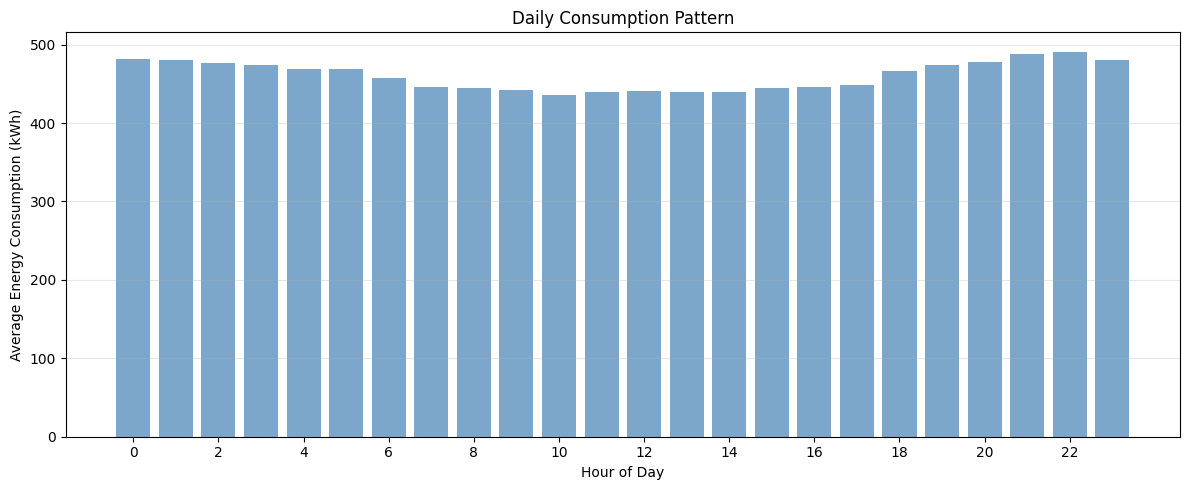


Peak Demand Reduction Scenarios:
Peak hours: [7, 8, 9, 17, 18, 19]

Load shedding  5% during peak hours:
  Original: 507855.49 kWh
  After reduction: 475291.76 kWh
  Energy saved: 32563.73 kWh (32.56 MWh)

Load shedding 10% during peak hours:
  Original: 507855.49 kWh
  After reduction: 451316.20 kWh
  Energy saved: 56539.29 kWh (56.54 MWh)

Load shedding 15% during peak hours:
  Original: 507855.49 kWh
  After reduction: 433663.33 kWh
  Energy saved: 74192.16 kWh (74.19 MWh)

Load shedding 20% during peak hours:
  Original: 507855.49 kWh
  After reduction: 420665.40 kWh
  Energy saved: 87190.08 kWh (87.19 MWh)



In [37]:
min_len = min(
    len(dual_preds),
    len(y_test),
    len(common_indices[split:])
)


dual_preds_sync = dual_preds[:min_len]
y_test_sync = y_test[:min_len]
hours_sync = df_clean['hour'].iloc[common_indices[split:]][:min_len].values

hourly_consumption = []
for hour in range(24):
    hour_mask = hours_sync == hour
    if hour_mask.any():
        hourly_consumption.append(np.mean(np.expm1(y_test_sync[hour_mask])))
    else:
        hourly_consumption.append(0)

plt.figure(figsize=(12, 5))
plt.bar(range(24), hourly_consumption, alpha=0.7, color='steelblue')
plt.xlabel('Hour of Day')
plt.ylabel('Average Energy Consumption (kWh)')
plt.title('Daily Consumption Pattern')
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

peak_hours = [7, 8, 9, 17, 18, 19]
reduction_scenarios = [5, 10, 15, 20]

print("\nPeak Demand Reduction Scenarios:")
print(f"Peak hours: {peak_hours}")
print()

for reduction in reduction_scenarios:
    preds_reduced = dual_preds_sync.copy()
    
    for hour in peak_hours:
        hour_mask = hours_sync == hour
        preds_reduced[hour_mask] = preds_reduced[hour_mask] * (1 - reduction/100)
    
    total_original = np.sum(np.expm1(dual_preds_sync))
    total_reduced = np.sum(np.expm1(preds_reduced))
    saved_energy = total_original - total_reduced
    
    print(f"Load shedding {reduction:2d}% during peak hours:")
    print(f"  Original: {total_original:.2f} kWh")
    print(f"  After reduction: {total_reduced:.2f} kWh")
    print(f"  Energy saved: {saved_energy:.2f} kWh ({saved_energy/1000:.2f} MWh)")
    print()

Baseline Electricity Cost: $58215.91

Optimization Scenario (20% peak load shift):
Optimized Cost: $54855.58
Cost Savings: $3360.33 (5.8%)


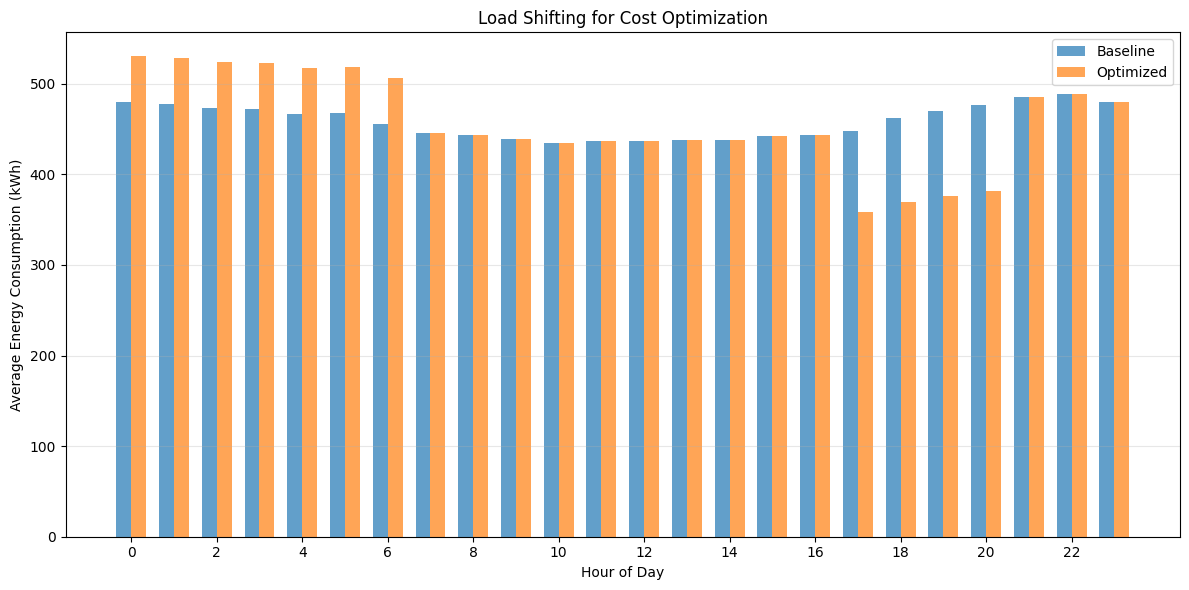

In [38]:
min_len = min(len(dual_preds), len(common_indices[split:]), len(y_test))

dual_preds_sync = dual_preds[:min_len]
y_test_sync = y_test[:min_len]
hours_sync = df_clean['hour'].iloc[common_indices[split:]][:min_len].values


tou_prices = {
    'Off-Peak': {'hours': range(0, 7), 'price': 0.05},      
    'Mid-Peak': {'hours': range(7, 17), 'price': 0.12},     
    'Peak': {'hours': range(17, 21), 'price': 0.25},        
    'Evening': {'hours': range(21, 24), 'price': 0.08}     
}

hourly_prices = np.zeros(24)
for period, info in tou_prices.items():
    for hour in info['hours']:
        hourly_prices[hour] = info['price']

energy_consumption = np.expm1(dual_preds_sync)

baseline_cost = np.sum(energy_consumption * hourly_prices[hours_sync])
print(f"Baseline Electricity Cost: ${baseline_cost:.2f}")

energy_shifted = energy_consumption.copy()
peak_mask = np.isin(hours_sync, tou_prices['Peak']['hours'])
offpeak_mask = np.isin(hours_sync, tou_prices['Off-Peak']['hours'])

shift_amount = 0.2 
peak_consumption = energy_consumption[peak_mask].sum()
shift_energy = peak_consumption * shift_amount

energy_shifted[peak_mask] = energy_shifted[peak_mask] * (1 - shift_amount)
if offpeak_mask.any():
    energy_shifted[offpeak_mask] += shift_energy / offpeak_mask.sum()

optimized_cost = np.sum(energy_shifted * hourly_prices[hours_sync])
cost_savings = baseline_cost - optimized_cost

print(f"\nOptimization Scenario (20% peak load shift):")
print(f"Optimized Cost: ${optimized_cost:.2f}")
print(f"Cost Savings: ${cost_savings:.2f} ({cost_savings/baseline_cost*100:.1f}%)")

hourly_original = []
hourly_shifted = []

for hour in range(24):
    hour_mask = hours_sync == hour
    if hour_mask.any():
        hourly_original.append(np.mean(energy_consumption[hour_mask]))
        hourly_shifted.append(np.mean(energy_shifted[hour_mask]))
    else:
        hourly_original.append(0)
        hourly_shifted.append(0)

x = np.arange(24)
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, hourly_original, width, label='Baseline', alpha=0.7)
plt.bar(x + width/2, hourly_shifted, width, label='Optimized', alpha=0.7)

plt.xlabel('Hour of Day')
plt.ylabel('Average Energy Consumption (kWh)')
plt.title('Load Shifting for Cost Optimization')
plt.xticks(range(0, 24, 2))
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [39]:
summary_data = []

for r in temp_results:
    summary_data.append({
        'Scenario': f"Temp {r['delta_temp']:+d}°C",
        'Total Energy (kWh)': f"{r['total_energy']:.0f}",
        'Change (%)': f"{r['change_pct']:+.1f}%",
        'Impact': 'High' if abs(r['change_pct']) > 5 else 'Medium' if abs(r['change_pct']) > 2 else 'Low'
    })

for r in weather_results:
    summary_data.append({
        'Scenario': r['scenario'],
        'Total Energy (kWh)': f"{r['total_energy']:.0f}",
        'Change (%)': f"{r['change_pct']:+.1f}%",
        'Impact': 'High' if abs(r['change_pct']) > 5 else 'Medium' if abs(r['change_pct']) > 2 else 'Low'
    })

summary_df = pd.DataFrame(summary_data)
print("\nScenario Impact Summary:")
print(summary_df.to_string(index=False))


print("\n1. TEMPERATURE SENSITIVITY:")
for r in temp_results:
    if r['delta_temp'] == 2:
        print(f"   +2°C increases consumption by {r['change_pct']:.1f}%")
    if r['delta_temp'] == -2:
        print(f"   -2°C decreases consumption by {abs(r['change_pct']):.1f}%")

print("\n2. WEATHER IMPACT:")
for r in weather_results:
    if r['scenario'] == 'Heat Wave':
        print(f"   Heat wave increases consumption by {r['change_pct']:.1f}%")
    if r['scenario'] == 'Cold Snap':
        print(f"   Cold snap increases consumption by {r['change_pct']:.1f}%")

print("\n3. OPTIMIZATION POTENTIAL:")
print(f"   Peak load shifting can save ${cost_savings:.2f} per test period")


Scenario Impact Summary:
 Scenario Total Energy (kWh) Change (%) Impact
Temp -5°C             510916      +0.6%    Low
Temp -2°C             509420      +0.3%    Low
Temp +0°C             507855      +0.0%    Low
Temp +2°C             506475      -0.3%    Low
Temp +5°C             504612      -0.6%    Low
   Normal             507855      +0.0%    Low
Heat Wave             504612      -0.6%    Low
Cold Snap             510916      +0.6%    Low
   Stormy             507855      +0.0%    Low
   Cloudy             507855      +0.0%    Low
    Sunny             505808      -0.4%    Low

1. TEMPERATURE SENSITIVITY:
   -2°C decreases consumption by 0.3%
   +2°C increases consumption by -0.3%

2. WEATHER IMPACT:
   Heat wave increases consumption by -0.6%
   Cold snap increases consumption by 0.6%

3. OPTIMIZATION POTENTIAL:
   Peak load shifting can save $3360.33 per test period


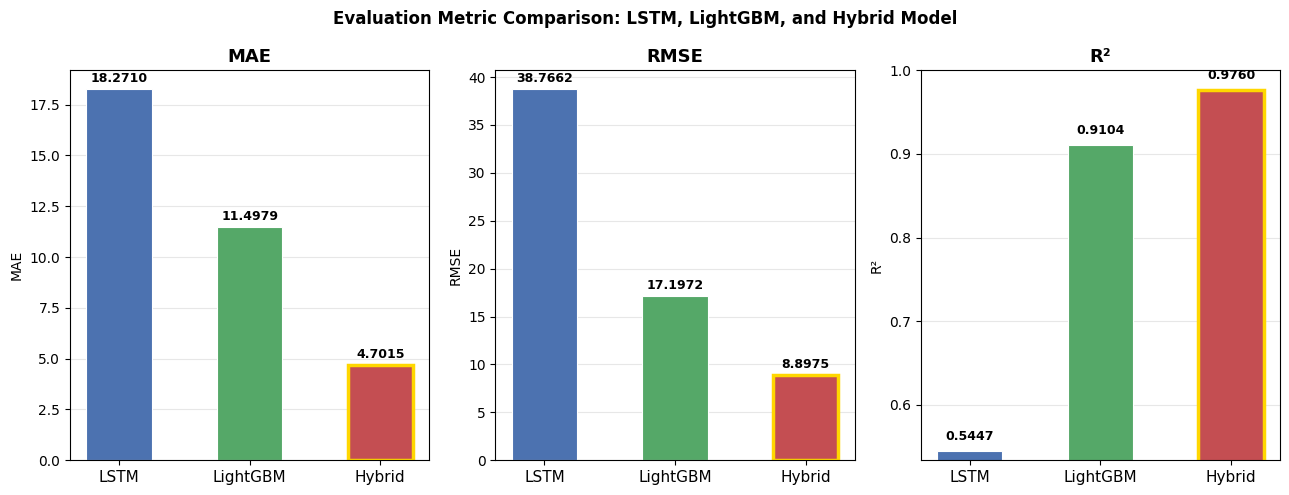

In [40]:
min_len = min(len(y_test), len(dual_preds), len(lstm_test_preds), len(lgb_test_preds))

y_true = np.expm1(y_test[:min_len])
dual_p = np.expm1(dual_preds[:min_len])
lstm_p = np.expm1(lstm_test_preds[:min_len])
lgb_p  = np.expm1(lgb_test_preds[:min_len])

metrics = {
    'MAE':  [mean_absolute_error(y_true, lstm_p),
             mean_absolute_error(y_true, lgb_p),
             mean_absolute_error(y_true, dual_p)],
    'RMSE': [np.sqrt(mean_squared_error(y_true, lstm_p)),
             np.sqrt(mean_squared_error(y_true, lgb_p)),
             np.sqrt(mean_squared_error(y_true, dual_p))],
    'R²':   [r2_score(y_true, lstm_p),
             r2_score(y_true, lgb_p),
             r2_score(y_true, dual_p)]
}

models = ['LSTM', 'LightGBM', 'Hybrid']
colors = ['#4C72B0', '#55A868', '#C44E52']
x = np.arange(len(models))
width = 0.25

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle('Evaluation Metric Comparison: LSTM, LightGBM, and Hybrid Model',
             fontsize=12, fontweight='bold')

for ax, (metric_name, values) in zip(axes, metrics.items()):
    bars = ax.bar(x, values, width=0.5, color=colors, edgecolor='white', linewidth=0.8)
   
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(values) * 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
   
    best_idx = np.argmin(values) if metric_name != 'R²' else np.argmax(values)
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(2.5)
    
    ax.set_title(metric_name, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.set_ylabel(metric_name, fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_axisbelow(True)
    
    if metric_name == 'R²':
        ax.set_ylim(min(values) * 0.98, 1.0)

plt.tight_layout()
plt.savefig('figure_4_2_metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
mae_lstm  = mean_absolute_error(y_true, lstm_p)
mae_lgb   = mean_absolute_error(y_true, lgb_p)
mae_dual  = mean_absolute_error(y_true, dual_p)

rmse_lstm = np.sqrt(mean_squared_error(y_true, lstm_p))
rmse_lgb  = np.sqrt(mean_squared_error(y_true, lgb_p))
rmse_dual = np.sqrt(mean_squared_error(y_true, dual_p))

r2_lstm   = r2_score(y_true, lstm_p)
r2_lgb    = r2_score(y_true, lgb_p)
r2_dual   = r2_score(y_true, dual_p)

print("=" * 55)
print(f"{'Comparison':<25} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("=" * 55)

print(f"{'Hybrid vs LSTM':<25} "
      f"{(mae_lstm  - mae_dual)  / mae_lstm  * 100:>7.1f}% "
      f"{(rmse_lstm - rmse_dual) / rmse_lstm * 100:>7.1f}% "
      f"{(r2_dual   - r2_lstm)   / abs(r2_lstm)  * 100:>7.1f}%")

print(f"{'Hybrid vs LightGBM':<25} "
      f"{(mae_lgb   - mae_dual)  / mae_lgb   * 100:>7.1f}% "
      f"{(rmse_lgb  - rmse_dual) / rmse_lgb  * 100:>7.1f}% "
      f"{(r2_dual   - r2_lgb)    / abs(r2_lgb)   * 100:>7.1f}%")

print("=" * 55)

Comparison                     MAE     RMSE       R²
Hybrid vs LSTM               74.3%    77.0%    79.2%
Hybrid vs LightGBM           59.1%    48.3%     7.2%


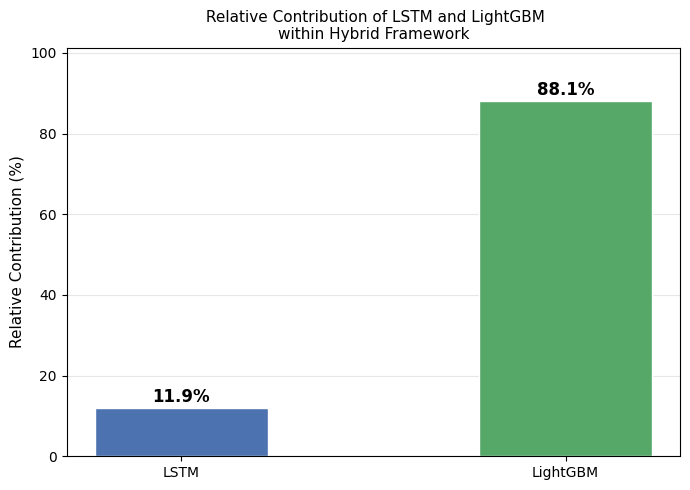

In [42]:
ridge_coefs = meta_model.coef_  
total = np.sum(np.abs(ridge_coefs))
contributions = np.abs(ridge_coefs) / total * 100

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(['LSTM', 'LightGBM'], contributions,
              color=['#4C72B0', '#55A868'], edgecolor='white', width=0.45)

for bar, val in zip(bars, contributions):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Relative Contribution (%)', fontsize=11)
ax.set_title(' Relative Contribution of LSTM and LightGBM\nwithin Hybrid Framework', fontsize=11)
ax.set_ylim(0, max(contributions) * 1.15)
ax.grid(True, alpha=0.3, axis='y')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('figure_4_6_contribution.png', dpi=150, bbox_inches='tight')
plt.show()

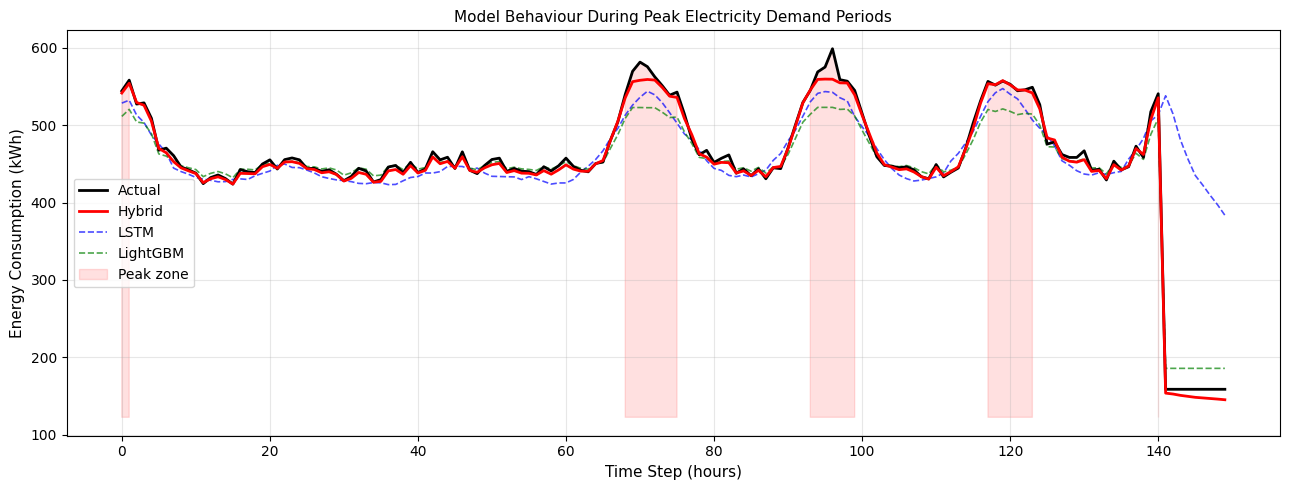

In [43]:
peak_threshold = np.percentile(y_true, 90)
peak_mask = y_true > peak_threshold
peak_indices = np.where(peak_mask)[0]

window_size = 150
first_peak = peak_indices[len(peak_indices)//3]
start = max(0, first_peak - window_size//2)
end   = min(len(y_true), start + window_size)

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(range(end-start), y_true[start:end],  'k-',  linewidth=2,   label='Actual',      zorder=3)
ax.plot(range(end-start), dual_p[start:end],  'r-',  linewidth=2,   label='Hybrid',      zorder=3)
ax.plot(range(end-start), lstm_p[start:end],  'b--', linewidth=1.2, label='LSTM',        alpha=0.7)
ax.plot(range(end-start), lgb_p[start:end],   'g--', linewidth=1.2, label='LightGBM',    alpha=0.7)

local_peaks = peak_mask[start:end]
ax.fill_between(range(end-start), ax.get_ylim()[0], y_true[start:end],
                where=local_peaks, alpha=0.12, color='red', label='Peak zone')

ax.set_xlabel('Time Step (hours)', fontsize=11)
ax.set_ylabel('Energy Consumption (kWh)', fontsize=11)
ax.set_title('Model Behaviour During Peak Electricity Demand Periods', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure_4_7_peak_demand.png', dpi=150, bbox_inches='tight')
plt.show()

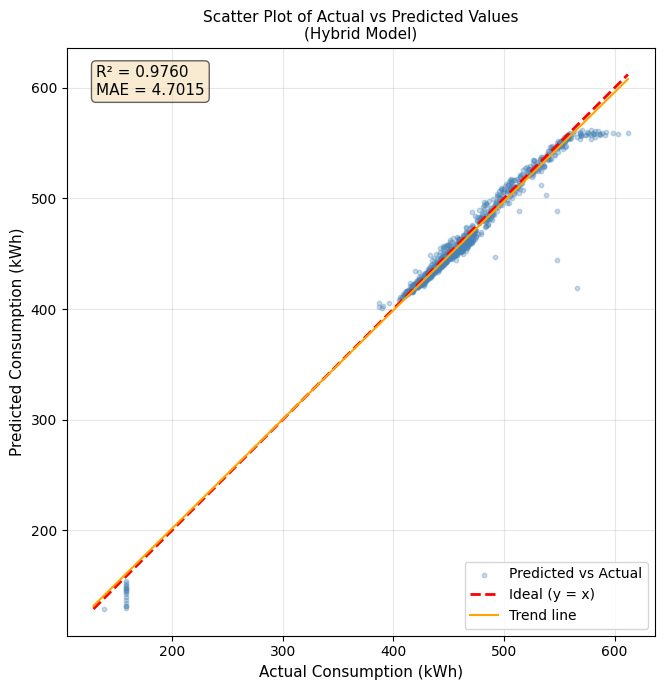

In [44]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(y_true, dual_p, alpha=0.3, s=10, color='steelblue', label='Predicted vs Actual')

lims = [min(y_true.min(), dual_p.min()), max(y_true.max(), dual_p.max())]
ax.plot(lims, lims, 'r--', linewidth=2, label='Ideal (y = x)')

z = np.polyfit(y_true, dual_p, 1)
p = np.poly1d(z)
x_line = np.linspace(lims[0], lims[1], 200)
ax.plot(x_line, p(x_line), 'orange', linewidth=1.5, label='Trend line')

r2 = r2_score(y_true, dual_p)
mae = mean_absolute_error(y_true, dual_p)
ax.text(0.05, 0.92, f'R² = {r2:.4f}\nMAE = {mae:.4f}',
        transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

ax.set_xlabel('Actual Consumption (kWh)', fontsize=11)
ax.set_ylabel('Predicted Consumption (kWh)', fontsize=11)
ax.set_title('Scatter Plot of Actual vs Predicted Values\n(Hybrid Model)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('figure_4_8_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

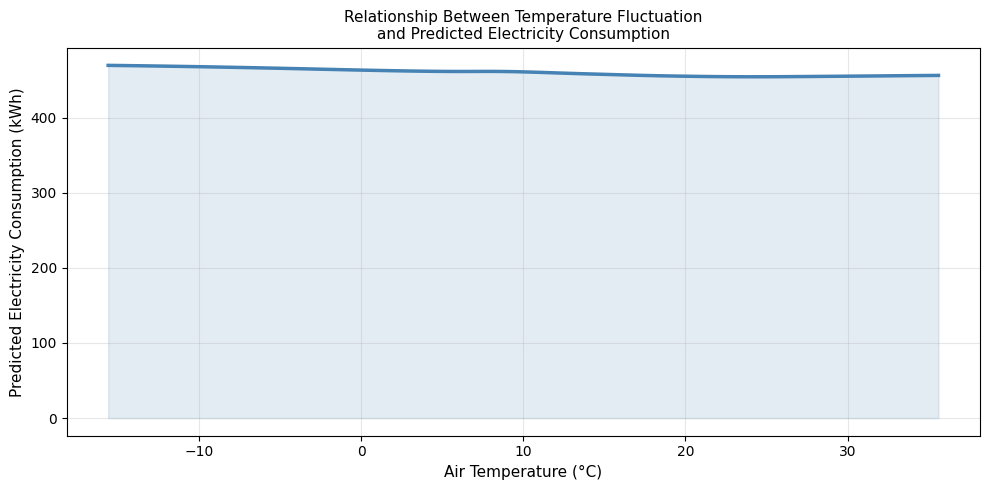

In [45]:
temp_range = np.linspace(df_clean['air_temperature'].min(), df_clean['air_temperature'].max(), 100)

preds_by_temp = []
for t in temp_range:
    preds = simulate_scenario(
        lstm_model, lgb_model, meta_model,
        X_lstm_test, X_ml_test,
        temp_change=t - df_clean['air_temperature'].mean()  # смещение от среднего
    )
    preds_by_temp.append(np.mean(np.expm1(preds)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(temp_range, preds_by_temp, color='steelblue', linewidth=2.5)
ax.fill_between(temp_range, preds_by_temp, alpha=0.15, color='steelblue')
ax.set_xlabel('Air Temperature (°C)', fontsize=11)
ax.set_ylabel('Predicted Electricity Consumption (kWh)', fontsize=11)
ax.set_title('Relationship Between Temperature Fluctuation\nand Predicted Electricity Consumption', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figure_4_9_temp_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

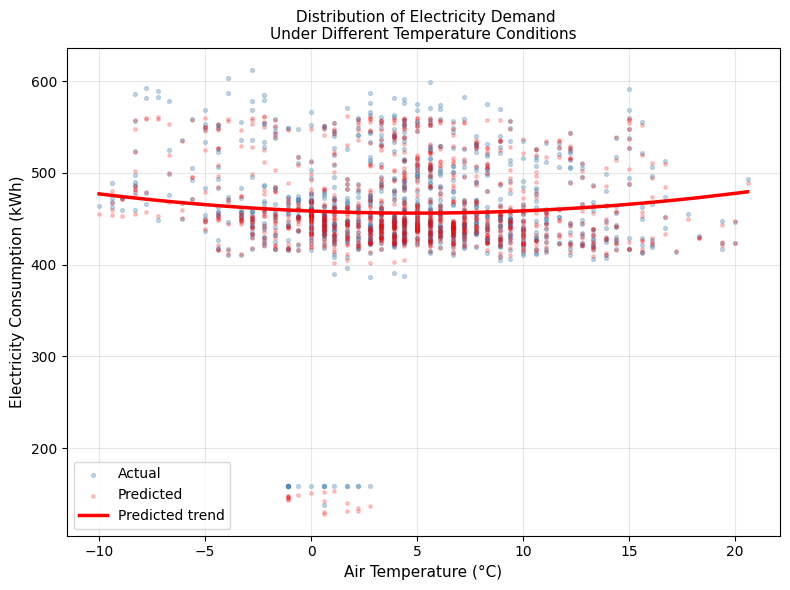

In [46]:
temps_test = df_clean['air_temperature'].values[-len(dual_preds):]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(temps_test, np.expm1(y_test), alpha=0.3, s=8, color='steelblue', label='Actual')
ax.scatter(temps_test, np.expm1(dual_preds), alpha=0.2, s=6, color='red', label='Predicted')

z = np.polyfit(temps_test, np.expm1(dual_preds), 2)
p = np.poly1d(z)
t_sorted = np.sort(temps_test)
ax.plot(t_sorted, p(t_sorted), 'r-', linewidth=2.5, label='Predicted trend')

ax.set_xlabel('Air Temperature (°C)', fontsize=11)
ax.set_ylabel('Electricity Consumption (kWh)', fontsize=11)
ax.set_title(' Distribution of Electricity Demand\nUnder Different Temperature Conditions', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figure_4_10_temp_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

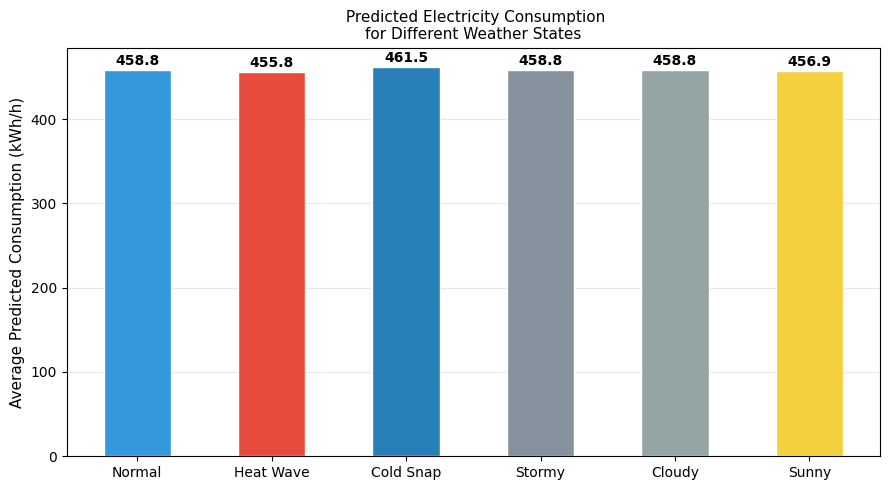

In [47]:
scenarios_names = [r['scenario'] for r in weather_results]
avg_energies    = [r['total_energy'] / len(dual_preds) for r in weather_results]
colors_sc = ['#3498DB', '#E74C3C', '#2980B9', '#85929E', '#95A5A6', '#F4D03F']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(scenarios_names, avg_energies, color=colors_sc, edgecolor='white', width=0.5)

for bar, val in zip(bars, avg_energies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(avg_energies)*0.005,
            f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Average Predicted Consumption (kWh/h)', fontsize=11)
ax.set_title(' Predicted Electricity Consumption\nfor Different Weather States', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('figure_4_11_weather_bar.png', dpi=150, bbox_inches='tight')
plt.show()

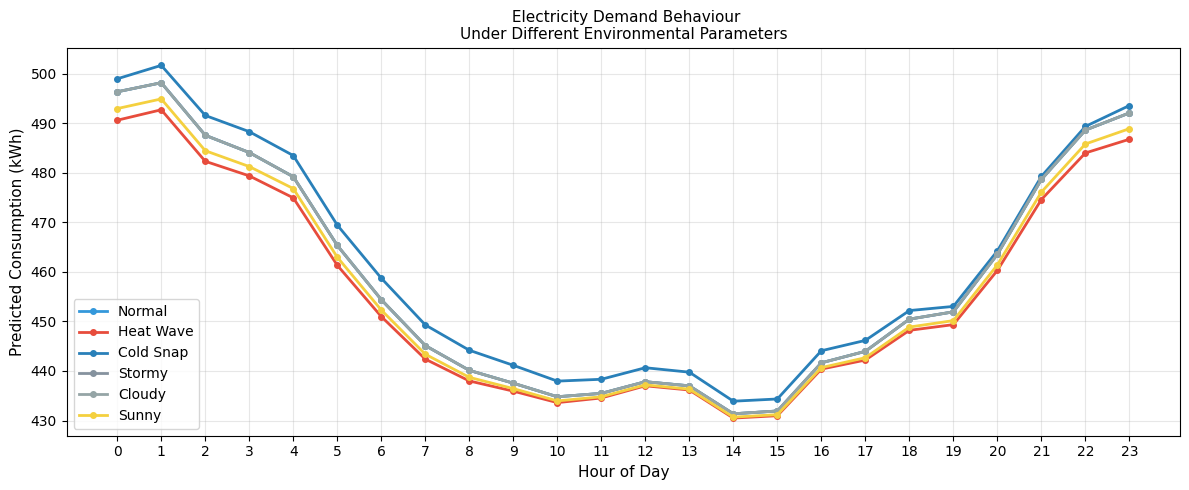

In [48]:
hours = np.arange(24)
colors_ln = ['#3498DB', '#E74C3C', '#2980B9', '#85929E', '#95A5A6', '#F4D03F']

hours_in_test = df_clean['hour'].values[-len(dual_preds):]

fig, ax = plt.subplots(figsize=(12, 5))

weather_scenarios_plot = {
    'Normal':     {},
    'Heat Wave':  {'air_temperature': +5,  'cloud_coverage': -20},
    'Cold Snap':  {'air_temperature': -5,  'cloud_coverage': +30},
    'Stormy':     {'wind_speed': +15,       'cloud_coverage': +40},
    'Cloudy':     {'cloud_coverage': +50},
    'Sunny':      {'cloud_coverage': -40,   'air_temperature': +3},
}

for (scenario_name, weather_changes), color in zip(weather_scenarios_plot.items(), colors_ln):
    preds_sc = simulate_scenario(
        lstm_model, lgb_model, meta_model,
        X_lstm_test, X_ml_test,
        weather_change=weather_changes
    )
    preds_orig = np.expm1(preds_sc)
    hourly_mean_sc = [np.mean(preds_orig[hours_in_test == h]) 
                      if (hours_in_test == h).any() else 0 for h in hours]
    ax.plot(hours, hourly_mean_sc, linewidth=2, label=scenario_name,
            color=color, marker='o', markersize=4)

ax.set_xlabel('Hour of Day', fontsize=11)
ax.set_ylabel('Predicted Consumption (kWh)', fontsize=11)
ax.set_title(' Electricity Demand Behaviour\nUnder Different Environmental Parameters', fontsize=11)
ax.set_xticks(hours)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figure_4_12_weather_lines.png', dpi=150, bbox_inches='tight')
plt.show()

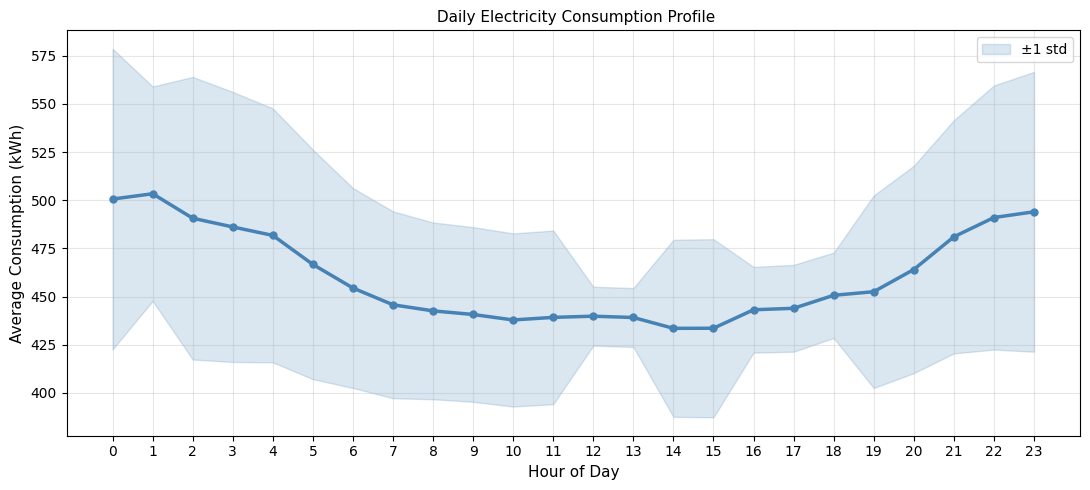

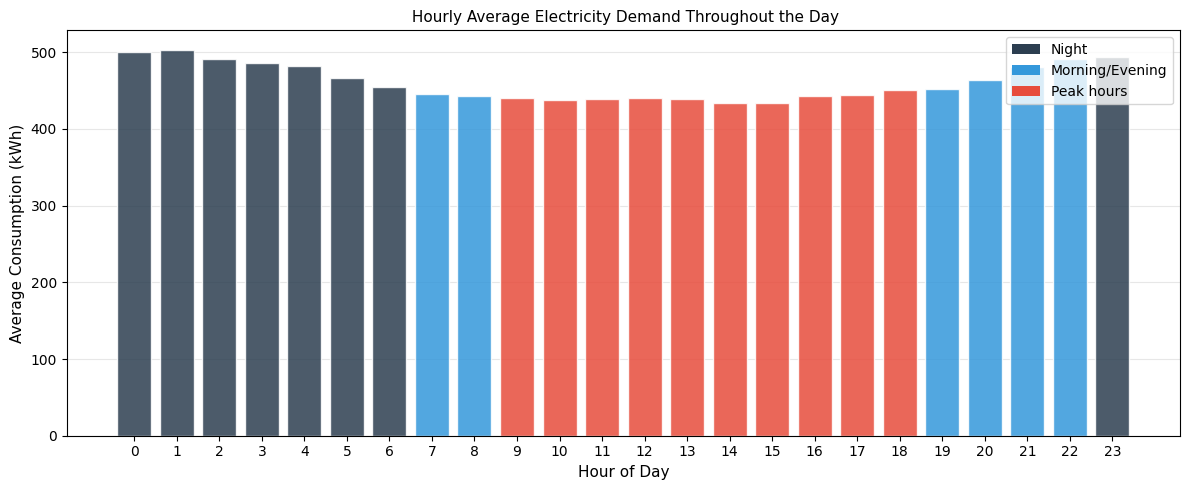

In [49]:
y_true_orig  = np.expm1(y_test)
hours_in_test = df_clean['hour'].values[-len(y_test):]

hourly_mean = [np.mean(y_true_orig[hours_in_test == h]) for h in range(24)]
hourly_std  = [np.std(y_true_orig[hours_in_test == h])  for h in range(24)]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(range(24), hourly_mean, color='steelblue', linewidth=2.5, marker='o', markersize=5)
ax.fill_between(range(24),
                np.array(hourly_mean) - np.array(hourly_std),
                np.array(hourly_mean) + np.array(hourly_std),
                alpha=0.2, color='steelblue', label='±1 std')
ax.set_xlabel('Hour of Day', fontsize=11)
ax.set_ylabel('Average Consumption (kWh)', fontsize=11)
ax.set_title(' Daily Electricity Consumption Profile', fontsize=11)
ax.set_xticks(range(24))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figure_4_13_daily_profile.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
colors_hour = ['#2C3E50' if (h < 7 or h > 22) else '#E74C3C' if (9 <= h <= 18) 
               else '#3498DB' for h in range(24)]
ax.bar(range(24), hourly_mean, color=colors_hour, edgecolor='white', alpha=0.85)
ax.set_xlabel('Hour of Day', fontsize=11)
ax.set_ylabel('Average Consumption (kWh)', fontsize=11)
ax.set_title(' Hourly Average Electricity Demand Throughout the Day', fontsize=11)
ax.set_xticks(range(24))
ax.grid(True, alpha=0.3, axis='y')
ax.set_axisbelow(True)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#2C3E50', label='Night'),
                   Patch(facecolor='#3498DB', label='Morning/Evening'),
                   Patch(facecolor='#E74C3C', label='Peak hours')], fontsize=10)
plt.tight_layout()
plt.savefig('figure_4_14_hourly_bar.png', dpi=150, bbox_inches='tight')
plt.show()

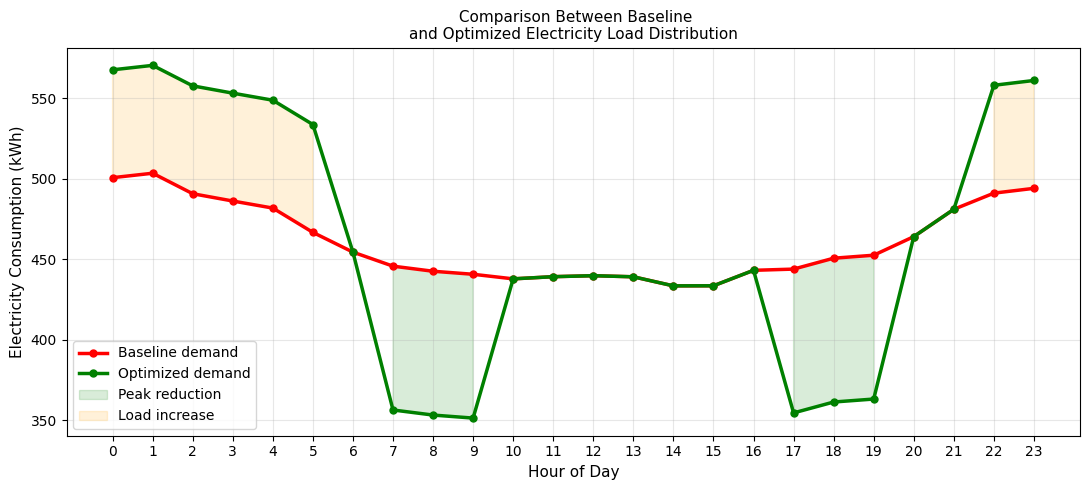

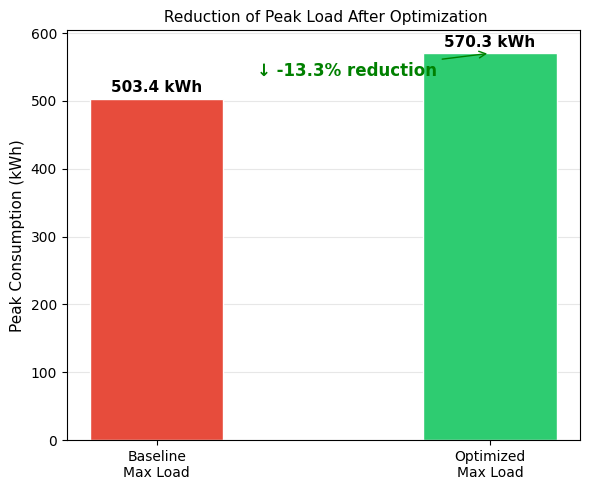

In [50]:
baseline_hourly  = np.array(hourly_mean)
optimized_hourly = baseline_hourly.copy()

peak_h   = [7, 8, 9, 17, 18, 19]
off_h    = list(range(0, 6)) + [22, 23]
shift    = np.mean(baseline_hourly[peak_h]) * 0.20  

for h in peak_h: optimized_hourly[h] -= shift
for h in off_h:  optimized_hourly[h] += shift * len(peak_h) / len(off_h)

# Fig 4.15
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(range(24), baseline_hourly,  'r-o', linewidth=2.5, markersize=5, label='Baseline demand')
ax.plot(range(24), optimized_hourly, 'g-o', linewidth=2.5, markersize=5, label='Optimized demand')
ax.fill_between(range(24), baseline_hourly, optimized_hourly,
                where=baseline_hourly > optimized_hourly,
                alpha=0.15, color='green', label='Peak reduction')
ax.fill_between(range(24), baseline_hourly, optimized_hourly,
                where=baseline_hourly < optimized_hourly,
                alpha=0.15, color='orange', label='Load increase')
ax.set_xlabel('Hour of Day', fontsize=11)
ax.set_ylabel('Electricity Consumption (kWh)', fontsize=11)
ax.set_title(' Comparison Between Baseline\nand Optimized Electricity Load Distribution', fontsize=11)
ax.set_xticks(range(24))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figure_4_15_load_shifting.png', dpi=150, bbox_inches='tight')
plt.show()

max_base = np.max(baseline_hourly)
max_opt  = np.max(optimized_hourly)
red_pct  = (max_base - max_opt) / max_base * 100

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(['Baseline\nMax Load', 'Optimized\nMax Load'],
              [max_base, max_opt],
              color=['#E74C3C', '#2ECC71'], edgecolor='white', width=0.4)
for bar, val in zip(bars, [max_base, max_opt]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max_base*0.01,
            f'{val:.1f} kWh', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.annotate(f'↓ {red_pct:.1f}% reduction',
            xy=(1, max_opt), xytext=(0.3, (max_base + max_opt)/2),
            fontsize=12, color='green', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='green'))
ax.set_ylabel('Peak Consumption (kWh)', fontsize=11)
ax.set_title(' Reduction of Peak Load After Optimization', fontsize=11)
ax.set_ylim(0, max_base * 1.2)
ax.grid(True, alpha=0.3, axis='y')
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('figure_4_16_peak_reduction.png', dpi=150, bbox_inches='tight')
plt.show()

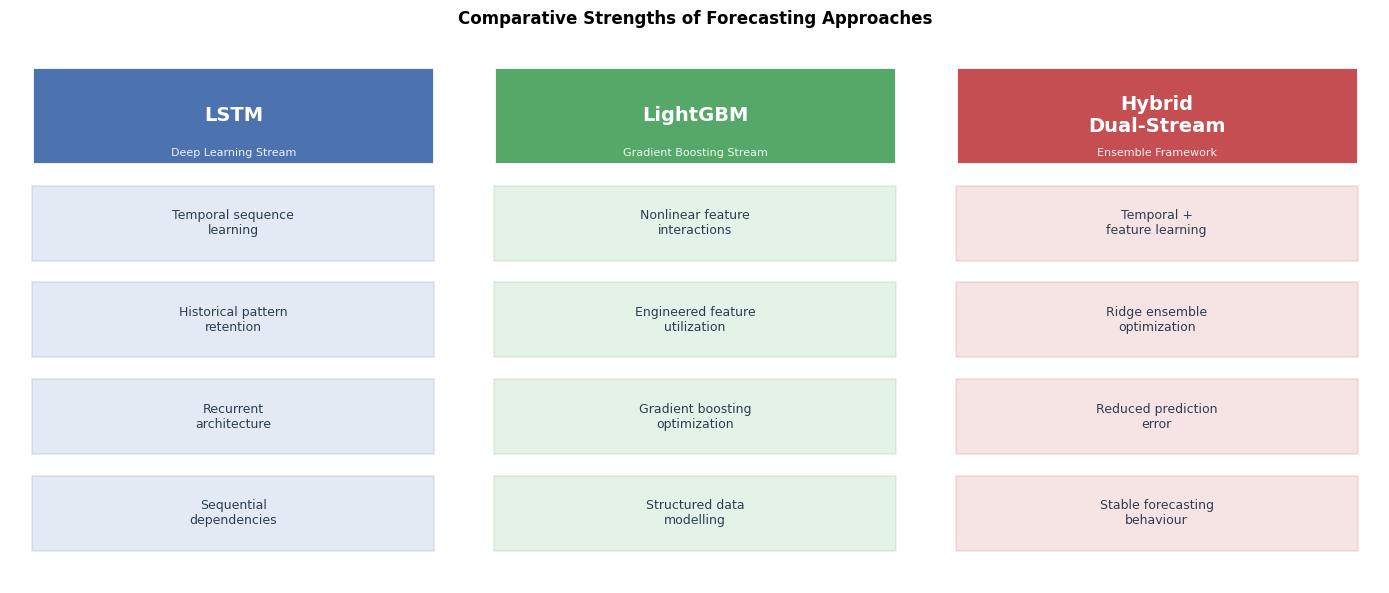

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6))
fig.suptitle('Comparative Strengths of Forecasting Approaches', 
             fontsize=12, fontweight='bold')

models_info = [
    {
        'title': 'LSTM',
        'color': '#4C72B0',
        'strengths': ['Temporal sequence\nlearning', 'Historical pattern\nretention', 'Recurrent\narchitecture', 'Sequential\ndependencies'],
        'subtitle': 'Deep Learning Stream'
    },
    {
        'title': 'LightGBM',
        'color': '#55A868',
        'strengths': ['Nonlinear feature\ninteractions', 'Engineered feature\nutilization', 'Gradient boosting\noptimization', 'Structured data\nmodelling'],
        'subtitle': 'Gradient Boosting Stream'
    },
    {
        'title': 'Hybrid\nDual-Stream',
        'color': '#C44E52',
        'strengths': ['Temporal +\nfeature learning', 'Ridge ensemble\noptimization', 'Reduced prediction\nerror', 'Stable forecasting\nbehaviour'],
        'subtitle': 'Ensemble Framework'
    }
]

for ax, info in zip(axes, models_info):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    
    ax.add_patch(plt.Rectangle((0.05, 0.78), 0.9, 0.18,
                                facecolor=info['color'], edgecolor='white', linewidth=2,
                                transform=ax.transAxes))
    ax.text(0.5, 0.87, info['title'], ha='center', va='center',
            fontsize=14, fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(0.5, 0.80, info['subtitle'], ha='center', va='center',
            fontsize=8, color='white', alpha=0.9, transform=ax.transAxes)
   
    for j, strength in enumerate(info['strengths']):
        y_pos = 0.60 - j * 0.18
        ax.add_patch(plt.Rectangle((0.05, y_pos), 0.9, 0.14,
                                    facecolor=info['color'], alpha=0.15,
                                    edgecolor=info['color'], linewidth=1.2,
                                    transform=ax.transAxes))
        ax.text(0.5, y_pos + 0.07, strength, ha='center', va='center',
                fontsize=9, color='#2C3E50', transform=ax.transAxes)

plt.tight_layout()
plt.savefig('figure_4_17_model_strengths.png', dpi=150, bbox_inches='tight')
plt.show()

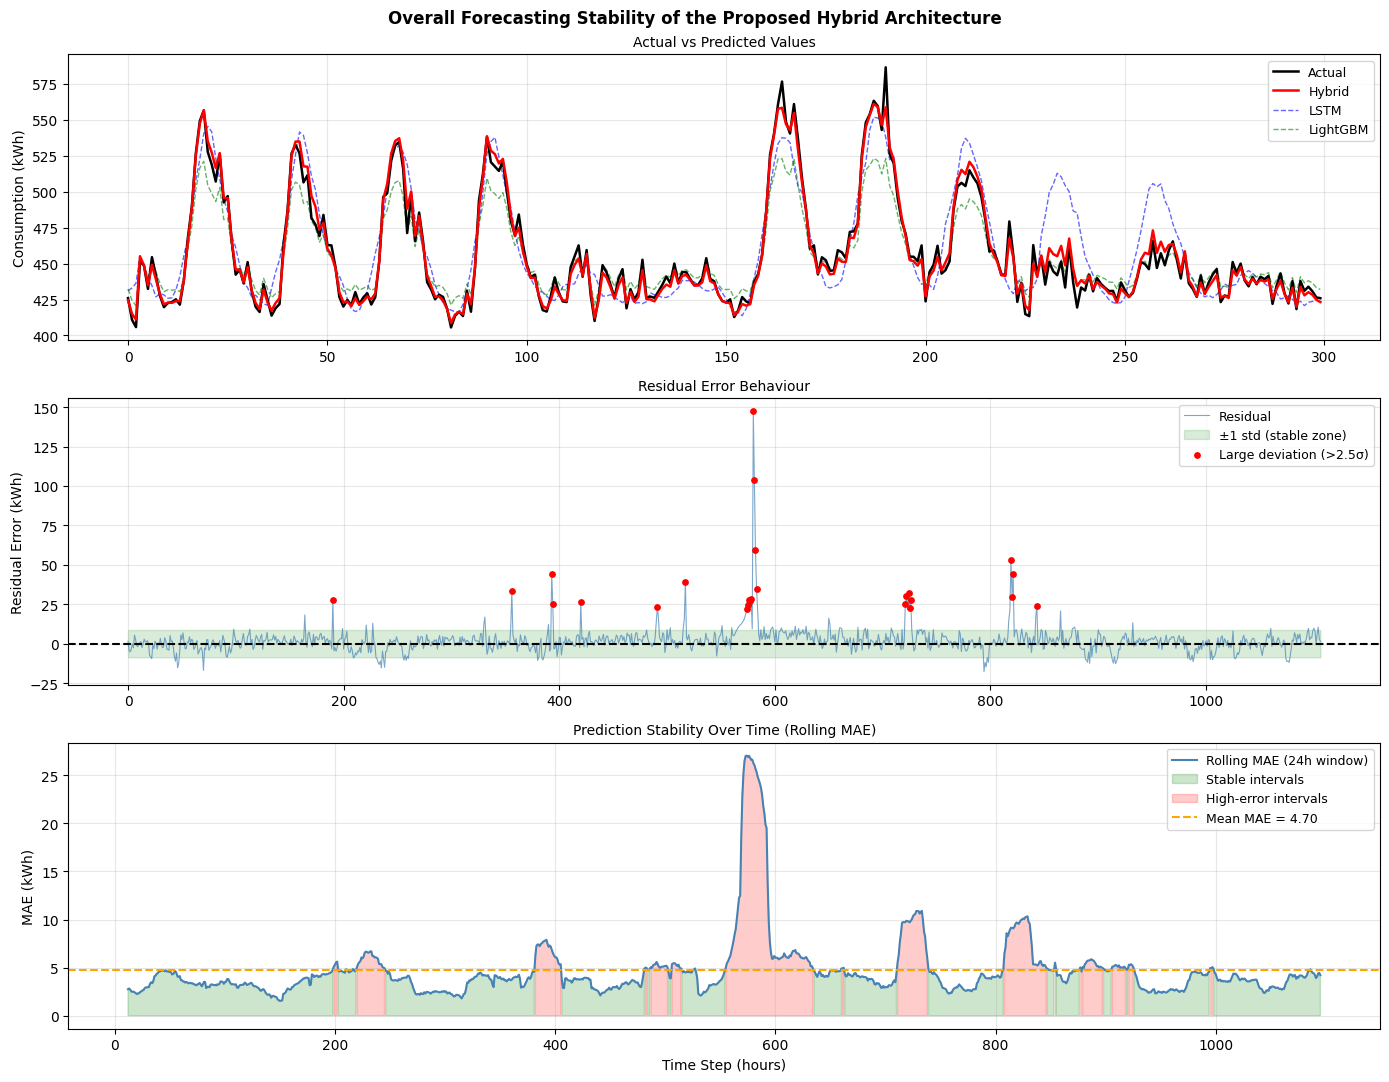

In [52]:
min_len = min(len(y_test), len(dual_preds), len(lstm_test_preds), len(lgb_test_preds))

y_original    = np.expm1(y_test[:min_len])
dual_original = np.expm1(dual_preds[:min_len])
lstm_original = np.expm1(lstm_test_preds[:min_len])
lgb_original  = np.expm1(lgb_test_preds[:min_len])

residuals_dual = y_original - dual_original
fig, axes = plt.subplots(3, 1, figsize=(14, 11))
fig.suptitle('Overall Forecasting Stability of the Proposed Hybrid Architecture',
             fontsize=12, fontweight='bold')

ax = axes[0]
n = min(300, len(y_original))
ax.plot(range(n), y_original[:n],     'k-',  linewidth=1.8, label='Actual',      zorder=3)
ax.plot(range(n), dual_original[:n],  'r-',  linewidth=1.8, label='Hybrid',      zorder=3)
ax.plot(range(n), lstm_original[:n],  'b--', linewidth=1.0, label='LSTM',        alpha=0.6)
ax.plot(range(n), lgb_original[:n],   'g--', linewidth=1.0, label='LightGBM',    alpha=0.6)
ax.set_ylabel('Consumption (kWh)', fontsize=10)
ax.set_title('Actual vs Predicted Values', fontsize=10)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(residuals_dual, color='steelblue', linewidth=0.8, alpha=0.7, label='Residual')
ax.axhline(0, color='black', linestyle='--', linewidth=1.5)
ax.fill_between(range(len(residuals_dual)),
                -np.std(residuals_dual), np.std(residuals_dual),
                alpha=0.15, color='green', label='±1 std (stable zone)')
threshold = 2.5 * np.std(residuals_dual)
outlier_mask = np.abs(residuals_dual) > threshold
ax.scatter(np.where(outlier_mask)[0], residuals_dual[outlier_mask],
           color='red', s=15, zorder=5, label='Large deviation (>2.5σ)')
ax.set_ylabel('Residual Error (kWh)', fontsize=10)
ax.set_title('Residual Error Behaviour', fontsize=10)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)

ax = axes[2]
window_roll = 24
abs_errors = np.abs(residuals_dual)
rolling_mae = pd.Series(abs_errors).rolling(window=window_roll, center=True).mean()
stable_mask = rolling_mae < np.percentile(rolling_mae.dropna(), 75)

ax.plot(rolling_mae, color='steelblue', linewidth=1.5, label=f'Rolling MAE ({window_roll}h window)')
ax.fill_between(range(len(rolling_mae)),
                rolling_mae,
                where=stable_mask,
                alpha=0.2, color='green', label='Stable intervals')
ax.fill_between(range(len(rolling_mae)),
                rolling_mae,
                where=~stable_mask,
                alpha=0.2, color='red', label='High-error intervals')
ax.axhline(np.mean(abs_errors), color='orange', linestyle='--', 
           linewidth=1.5, label=f'Mean MAE = {np.mean(abs_errors):.2f}')
ax.set_xlabel('Time Step (hours)', fontsize=10)
ax.set_ylabel('MAE (kWh)', fontsize=10)
ax.set_title('Prediction Stability Over Time (Rolling MAE)', fontsize=10)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure_4_18_forecasting_stability.png', dpi=150, bbox_inches='tight')
plt.show()

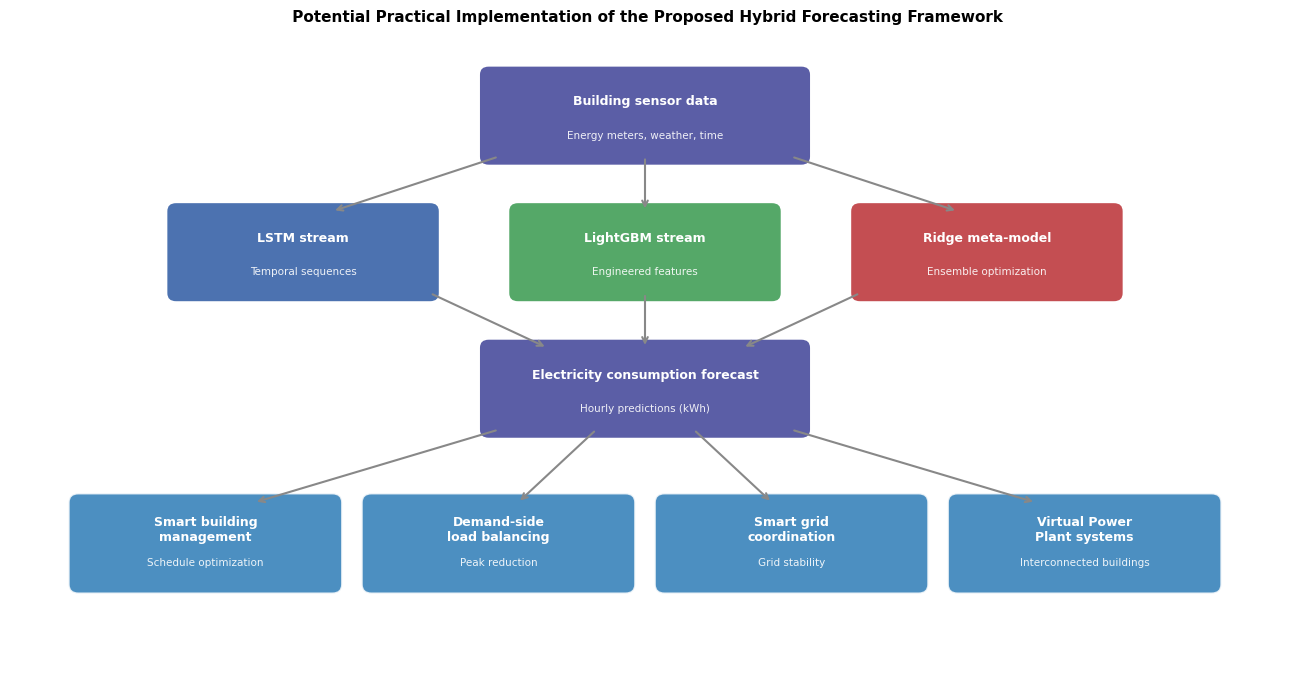

In [53]:
fig, ax = plt.subplots(figsize=(13, 7))
ax.set_xlim(0, 13)
ax.set_ylim(0, 7)
ax.axis('off')

from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def draw_box(ax, x, y, w, h, label, sublabel=None, color='#4C72B0', alpha=1.0):
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                          boxstyle="round,pad=0.1",
                          facecolor=color, edgecolor='white',
                          linewidth=1.5, alpha=alpha)
    ax.add_patch(box)
    if sublabel:
        ax.text(x, y + 0.15, label, ha='center', va='center',
                fontsize=9, fontweight='bold', color='white')
        ax.text(x, y - 0.22, sublabel, ha='center', va='center',
                fontsize=7.5, color='white', alpha=0.9)
    else:
        ax.text(x, y, label, ha='center', va='center',
                fontsize=9, fontweight='bold', color='white')

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#888888',
                                lw=1.5, connectionstyle='arc3,rad=0'))

draw_box(ax, 6.5, 6.2, 3.2, 0.9, 'Building sensor data',
         'Energy meters, weather, time', color='#5B5EA6')

draw_box(ax, 3.0, 4.7, 2.6, 0.9, 'LSTM stream',
         'Temporal sequences', color='#4C72B0')
draw_box(ax, 6.5, 4.7, 2.6, 0.9, 'LightGBM stream',
         'Engineered features', color='#55A868')
draw_box(ax, 10.0, 4.7, 2.6, 0.9, 'Ridge meta-model',
         'Ensemble optimization', color='#C44E52')

draw_box(ax, 6.5, 3.2, 3.2, 0.9, 'Electricity consumption forecast',
         'Hourly predictions (kWh)', color='#5B5EA6')

draw_box(ax, 2.0, 1.5, 2.6, 0.9, 'Smart building\nmanagement',
         'Schedule optimization', color='#2C7BB6', alpha=0.85)
draw_box(ax, 5.0, 1.5, 2.6, 0.9, 'Demand-side\nload balancing',
         'Peak reduction', color='#2C7BB6', alpha=0.85)
draw_box(ax, 8.0, 1.5, 2.6, 0.9, 'Smart grid\ncoordination',
         'Grid stability', color='#2C7BB6', alpha=0.85)
draw_box(ax, 11.0, 1.5, 2.6, 0.9, 'Virtual Power\nPlant systems',
         'Interconnected buildings', color='#2C7BB6', alpha=0.85)

draw_arrow(ax, 5.0, 5.75, 3.3, 5.15)
draw_arrow(ax, 6.5, 5.75, 6.5, 5.15)
draw_arrow(ax, 8.0, 5.75, 9.7, 5.15)

draw_arrow(ax, 4.3, 4.25, 5.5, 3.65)
draw_arrow(ax, 6.5, 4.25, 6.5, 3.65)
draw_arrow(ax, 8.7, 4.25, 7.5, 3.65)

draw_arrow(ax, 5.0, 2.75, 2.5, 1.95)
draw_arrow(ax, 6.0, 2.75, 5.2, 1.95)
draw_arrow(ax, 7.0, 2.75, 7.8, 1.95)
draw_arrow(ax, 8.0, 2.75, 10.5, 1.95)

ax.set_title(' Potential Practical Implementation of the Proposed Hybrid Forecasting Framework',
             fontsize=11, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('figure_4_19_implementation_flow.png', dpi=150, bbox_inches='tight')
plt.show()